# インド株 ファクター検証 — Step 5: 全コアファクターの一括比較

`data/factor/core.yaml` の 8 スタイル・100 ファクター（`Seasonality` を除く）を
Blom スコア化し、パフォーマンスと相互相関を行列で一望する。

## 見せ方の分担

- **パフォーマンス** → 縦棒チャート（x = ファクター、y = 年率超過リターン、スタイル色分け）
- **類似度** → ヒートマップ（相関・重複率のみ。対角はそのまま 1）

| ヒートマップ | 中身 | 想定用途 |
|---|---|---|
| A | スコアの順位相関（月次平均） | 銘柄の並べ方がどれだけ似ているか |
| B | **Q5 メンバーの重複率** | **ロングオンリー視点**: 併用時の銘柄の二重計上 |
| C | **Q5−Q1 リターン系列の相関** | 損益の出方の類似 = 分散効果（合成の設計はこれが本命） |

- 図Bの重複率は $|Q^a_5 \cap Q^b_5| / \sqrt{|Q^a_5||Q^b_5|}$。無相関なら $1/q = 0.20$ が基準
- `core.yaml` のスタイル階層は、行列の**色帯＋太い区切り線**で表示する

## 実装メモ

- スコア相関は月次クロスセクション Spearman の期間平均。100×100 を高速に回すため
  「列ごとに1回ランク → ペアワイズ共通有効サンプルで内積」で計算しており、
  完全ケースでは pandas と厳密一致、欠損があるペアでは pandas（ペアごとに再ランク）と
  最大 0.02 程度ずれる（検算済み。順序の判断には影響しない）
- 対角の年率超過は幾何（Step 1 の規約と同じ）

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.4f}")

START, END = 200701, 202607
METHOD = "blom"
Q = 5
WEIGHTING = "ew"   # 分位ポートのウェイト（"cw" に変えると全表・全図が時価総額ウェイトになる）

## 1. スタイル定義の読み込みとスコア化

In [2]:
style_map = fl.multi.load_style_map()          # Seasonality は既定で除外
factors, groups = fl.multi.flatten_styles(style_map)
print({k: len(v) for k, v in style_map.items()}, "-> total", len(factors))

panel = fl.data.build_panel(factors, start=START, end=END)
panel, score_cols = fl.multi.build_scores(panel, factors, method=METHOD)
panel.shape

{'Stock Value': 2, 'Flow Value': 18, 'Profitability': 25, 'Growth': 11, 'Shareholder Return': 5, 'Momentum': 9, 'Volatility': 2, 'Financial Quality': 28} -> total 100


(85493, 210)

In [3]:
# カバレッジの低いファクターに注意（LTG は 34% しかない）
cov = panel[factors].notna().mean().sort_values()
cov[cov < 0.7].to_frame("coverage").T

,ltg,rdp,ois_est,roic_est,roa_est
coverage,0.3436,0.4128,0.4342,0.4365,0.4402


## 2. スコアボード（全ファクターの分位分析 + IC を一括実行）

1行 = 1ファクター。`ls_*` が Q5−Q1、`top_*` が Q5（ロングオンリー側）。

In [4]:
scoreboard, results = fl.multi.factor_scoreboard(
    panel, score_cols, groups=groups, q=Q, weighting=WEIGHTING)

view_cols = ["style", "ls_ann_excess", "ls_IR", "ls_t_NW", "top_ann_excess", "top_IR",
             "top_t_NW", "mean_IC", "ICIR_ann", "ls_turnover_ann", "coverage"]
print("=== Q5-Q1 年率超過 上位15 ===")
display(scoreboard.sort_values("ls_ann_excess", ascending=False)[view_cols].head(15))
print("=== 下位10 ===")
display(scoreboard.sort_values("ls_ann_excess")[view_cols].head(10))

=== Q5-Q1 年率超過 上位15 ===


,style,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,ls_turnover_ann,coverage
rev3r,Momentum,0.1613,1.1311,5.0913,0.0987,0.9556,4.5282,0.0567,1.5821,8.1119,0.8883
rev3p,Momentum,0.1568,1.0230,4.5847,0.1051,0.9994,4.3515,0.0557,1.4334,7.8930,0.8883
rev1r,Momentum,0.1277,1.1809,5.0929,0.0704,0.7576,3.6673,0.0382,1.3752,16.9400,0.8987
rev1p,Momentum,0.1190,1.0368,4.3361,0.0755,0.8066,3.7231,0.0363,1.2459,16.6393,0.8987
dp_act,Flow Value,0.1053,0.9965,3.5589,0.0282,0.3559,1.5599,0.0376,1.3648,2.7761,0.9995
mom12,Momentum,0.0846,0.4756,2.0047,0.0536,0.4198,1.8575,0.0497,0.9038,6.2310,0.9990
mom12_1,Momentum,0.0803,0.4673,1.9741,0.0465,0.4025,1.7887,0.0550,1.0425,6.5149,0.9983
dp_est,Flow Value,0.0773,0.7605,2.6451,0.0422,0.4791,2.0841,0.0269,0.8895,3.0569,0.8575
doe,Shareholder Return,0.0708,0.4962,2.1849,0.0390,0.3583,1.6787,0.0478,1.1673,2.5541,0.9903
roe_act,Profitability,0.0616,0.4539,2.0415,0.0341,0.3433,1.4747,0.0381,0.9342,2.2538,0.9899


=== 下位10 ===


,style,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,ls_turnover_ann,coverage
dlt_gpa_5y,Profitability,-0.0913,-0.6687,-2.8674,-0.0589,-0.4420,-1.7104,-0.0106,-0.3033,2.5275,0.8219
dlt_gps_5y,Profitability,-0.0891,-0.8282,-3.0797,-0.0635,-0.3556,-1.4443,-0.0154,-0.5994,2.5343,0.8226
xfin_sp,Financial Quality,-0.0876,-0.9101,-3.6199,-0.0736,-0.4218,-1.8080,-0.0249,-1.1667,3.1534,0.9274
xfin_bs,Financial Quality,-0.0851,-0.5729,-2.4553,-0.0716,-0.3401,-1.5471,-0.0319,-0.9978,2.7644,0.9888
vola60,Volatility,-0.0826,-0.2334,-1.0395,-0.1017,-0.2513,-1.1484,-0.0532,-0.9271,2.2835,0.9983
csi,Shareholder Return,-0.0811,-0.7808,-3.0110,-0.0576,-0.2660,-1.2402,-0.0412,-1.5195,5.7692,0.9819
xfin_cf,Financial Quality,-0.0762,-0.4663,-2.0753,-0.0744,-0.3565,-1.6624,-0.0280,-0.7599,2.7124,0.9859
dlt_roa_5y,Profitability,-0.0655,-0.4764,-1.8809,-0.0580,-0.3998,-1.5582,-0.0015,-0.0430,2.2556,0.9026
zscore,Financial Quality,-0.0632,-0.2350,-0.9646,-0.0252,-0.2774,-1.2057,0.0135,0.2726,2.5766,0.8917
skew60,Volatility,-0.0624,-0.4402,-1.8791,-0.0677,-0.3347,-1.5402,-0.0335,-1.0483,2.9564,0.9977


In [5]:
# スタイル別の要約（構成ファクターの単純平均）
scoreboard.groupby("style")[["ls_ann_excess", "ls_IR", "top_ann_excess", "top_IR", "mean_IC"]].mean() \
    .reindex(style_map.keys())

,ls_ann_excess,ls_IR,top_ann_excess,top_IR,mean_IC
style,,,,,
Stock Value,-0.0128,0.0455,-0.0334,0.0266,-0.0184
Flow Value,0.0346,0.3368,-0.0001,0.1850,0.0071
Profitability,-0.0046,0.0189,-0.0046,0.0181,0.0136
Growth,-0.0198,-0.1533,-0.0362,-0.1109,-0.0055
Shareholder Return,0.0182,0.1654,-0.0003,0.0975,0.0118
Momentum,0.0807,0.6182,0.0411,0.4757,0.0313
Volatility,-0.0725,-0.3368,-0.0847,-0.2930,-0.0433
Financial Quality,-0.0196,-0.1024,-0.0193,-0.0455,-0.0009


### スコアボードの棒チャート

x軸 = ファクター（スタイルで色分け・スタイル内で値順）、y軸 = 年率超過リターン。
`*` は Newey-West |t| ≥ 2。

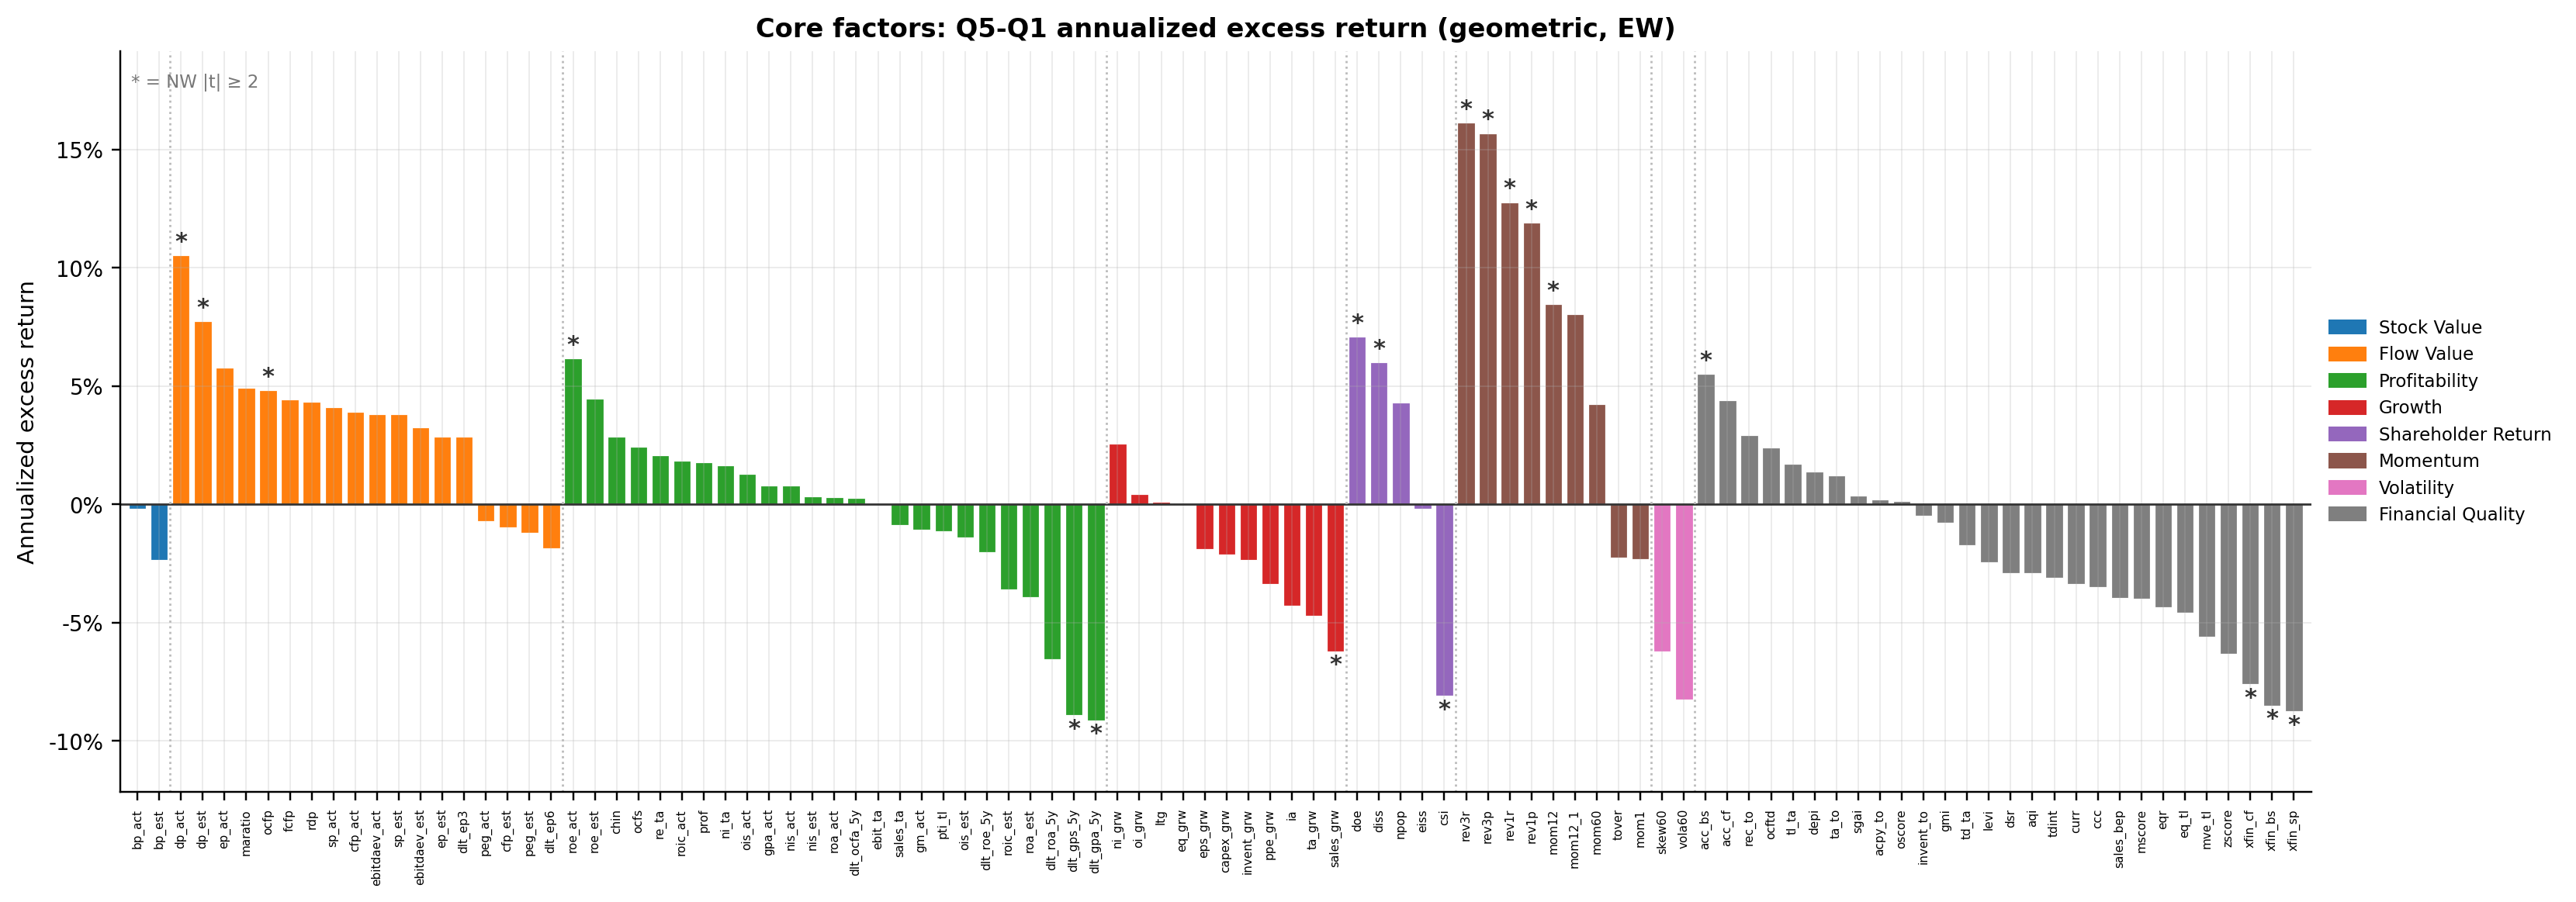

In [6]:
fig = fl.plotting.plot_scoreboard_bars(
    scoreboard, value_col="ls_ann_excess", tstat_col="ls_t_NW",
    title=f"Core factors: Q{Q}-Q1 annualized excess return (geometric, {WEIGHTING.upper()})")
fl.plotting.savefig(fig, "05_core_scan/40_scoreboard_ls");

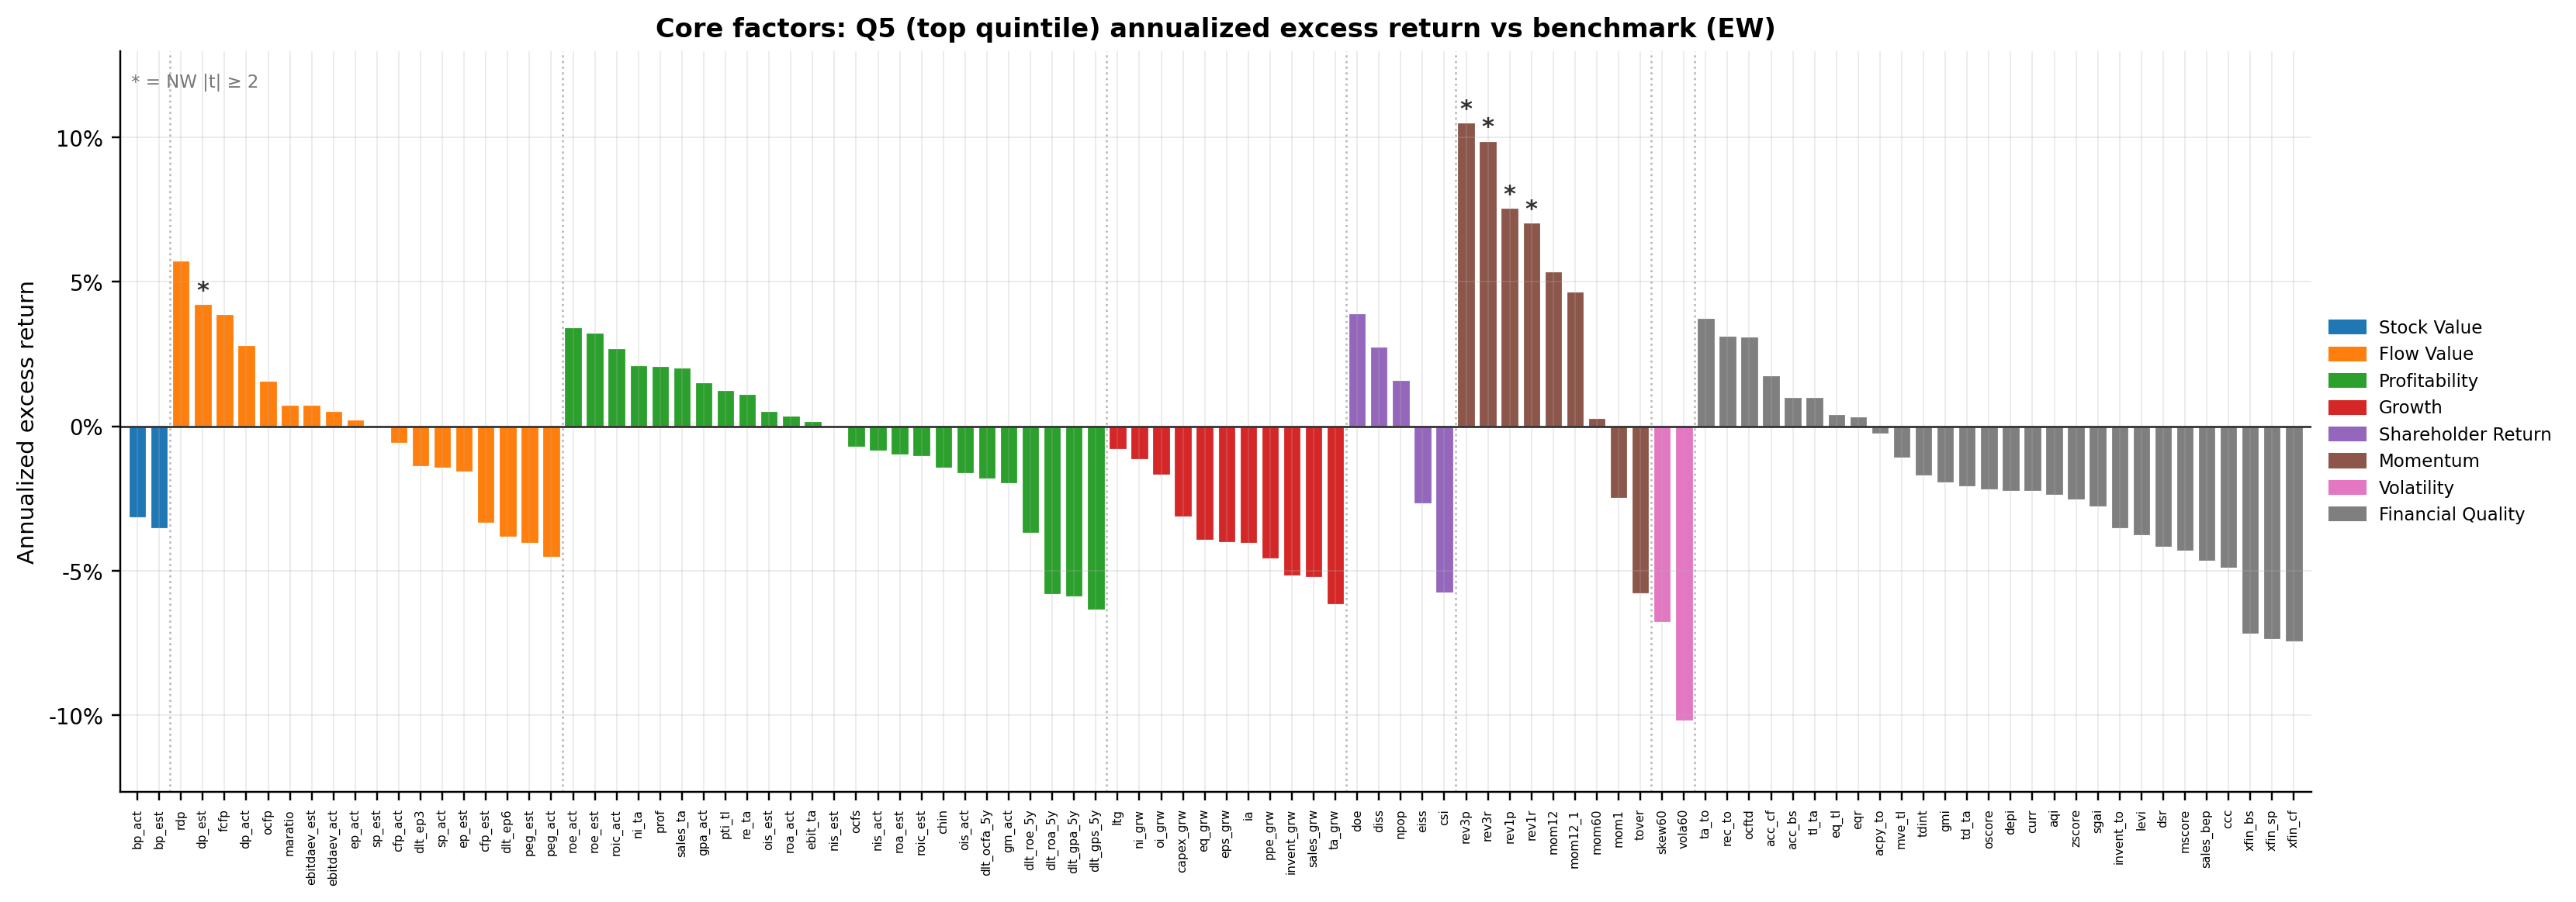

In [7]:
fig = fl.plotting.plot_scoreboard_bars(
    scoreboard, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Core factors: Q{Q} (top quintile) annualized excess return vs benchmark ({WEIGHTING.upper()})")
fl.plotting.savefig(fig, "05_core_scan/41_scoreboard_top");

## 3. 図A — スコアの順位相関

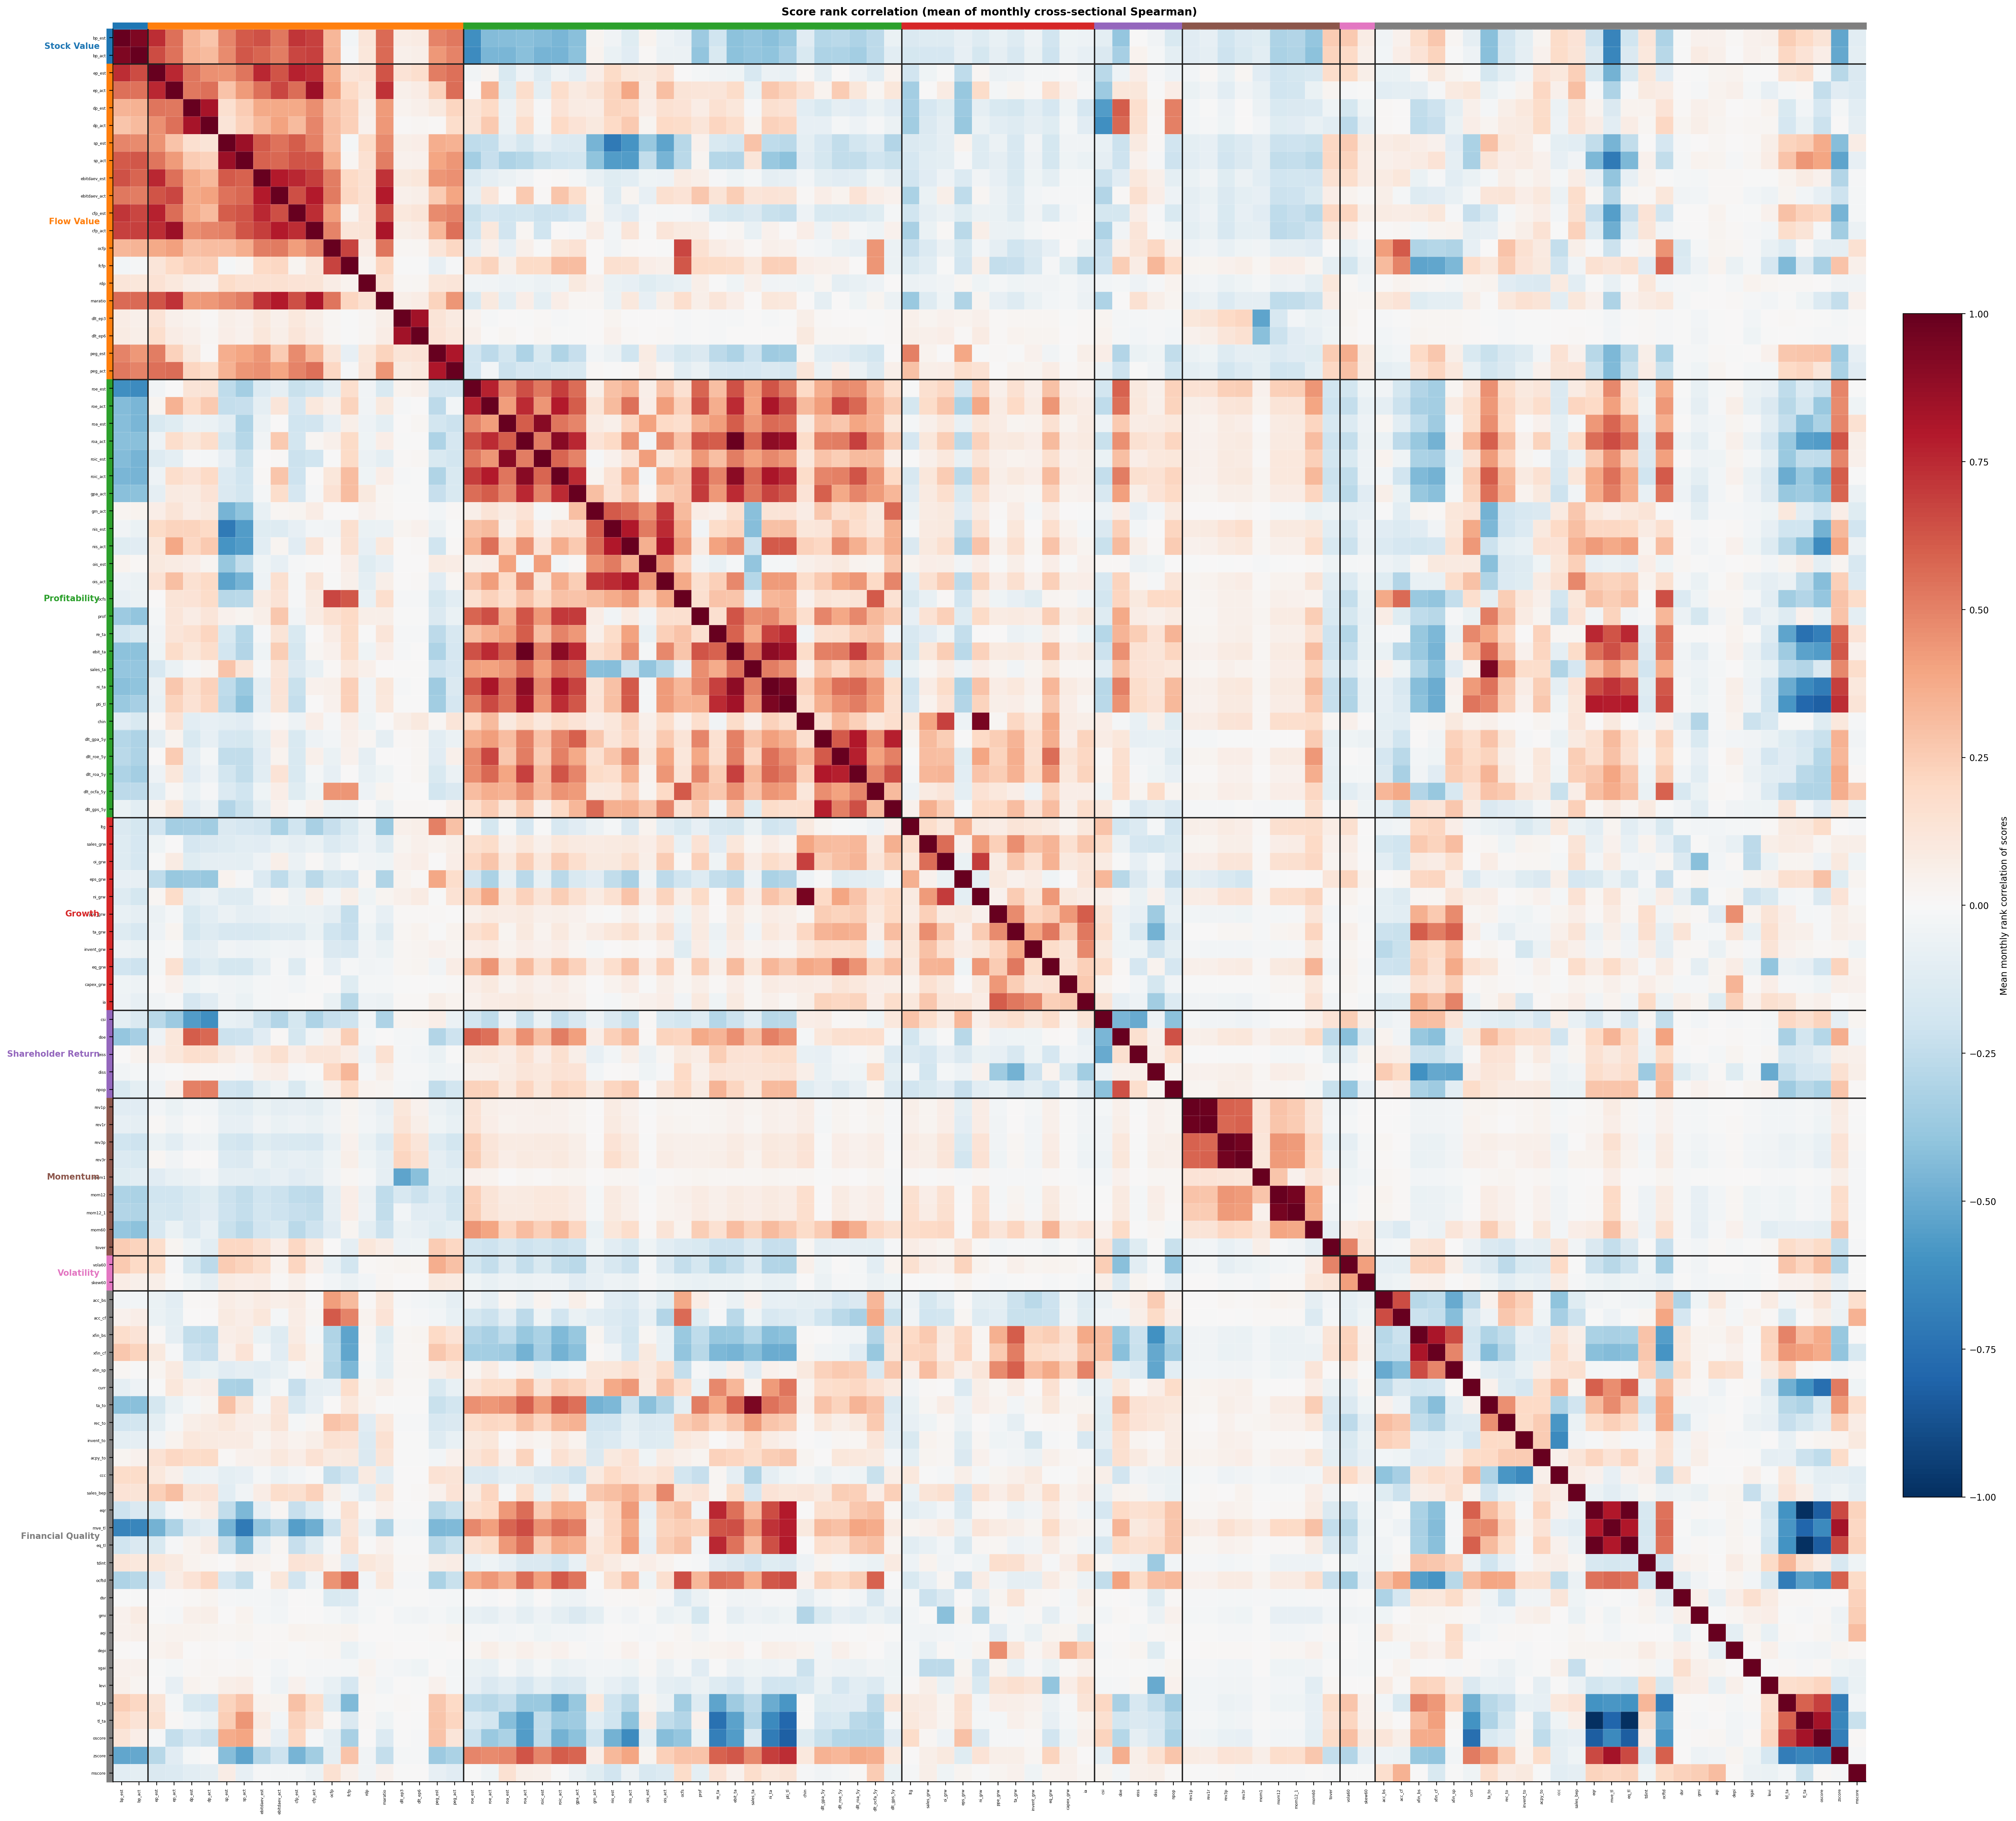

In [8]:
corr_score = fl.multi.cross_sectional_corr(panel, [score_cols[f] for f in factors], labels=factors)

fig = fl.plotting.plot_factor_matrix(
    corr_score, groups=groups,
    title="Score rank correlation (mean of monthly cross-sectional Spearman)",
    off_label="Mean monthly rank correlation of scores",
    off_vmin=-1, off_vmax=1, annotate=False)
fl.plotting.savefig(fig, "05_core_scan/42_matrix_score_corr");

## 4. 図B — ロングオンリー視点: Q5 メンバーの重複率

重複率は 0.20 が「無相関」の基準（5分位）。0.5 を超えるペアは
併用してもほぼ同じ銘柄を買うことになる。

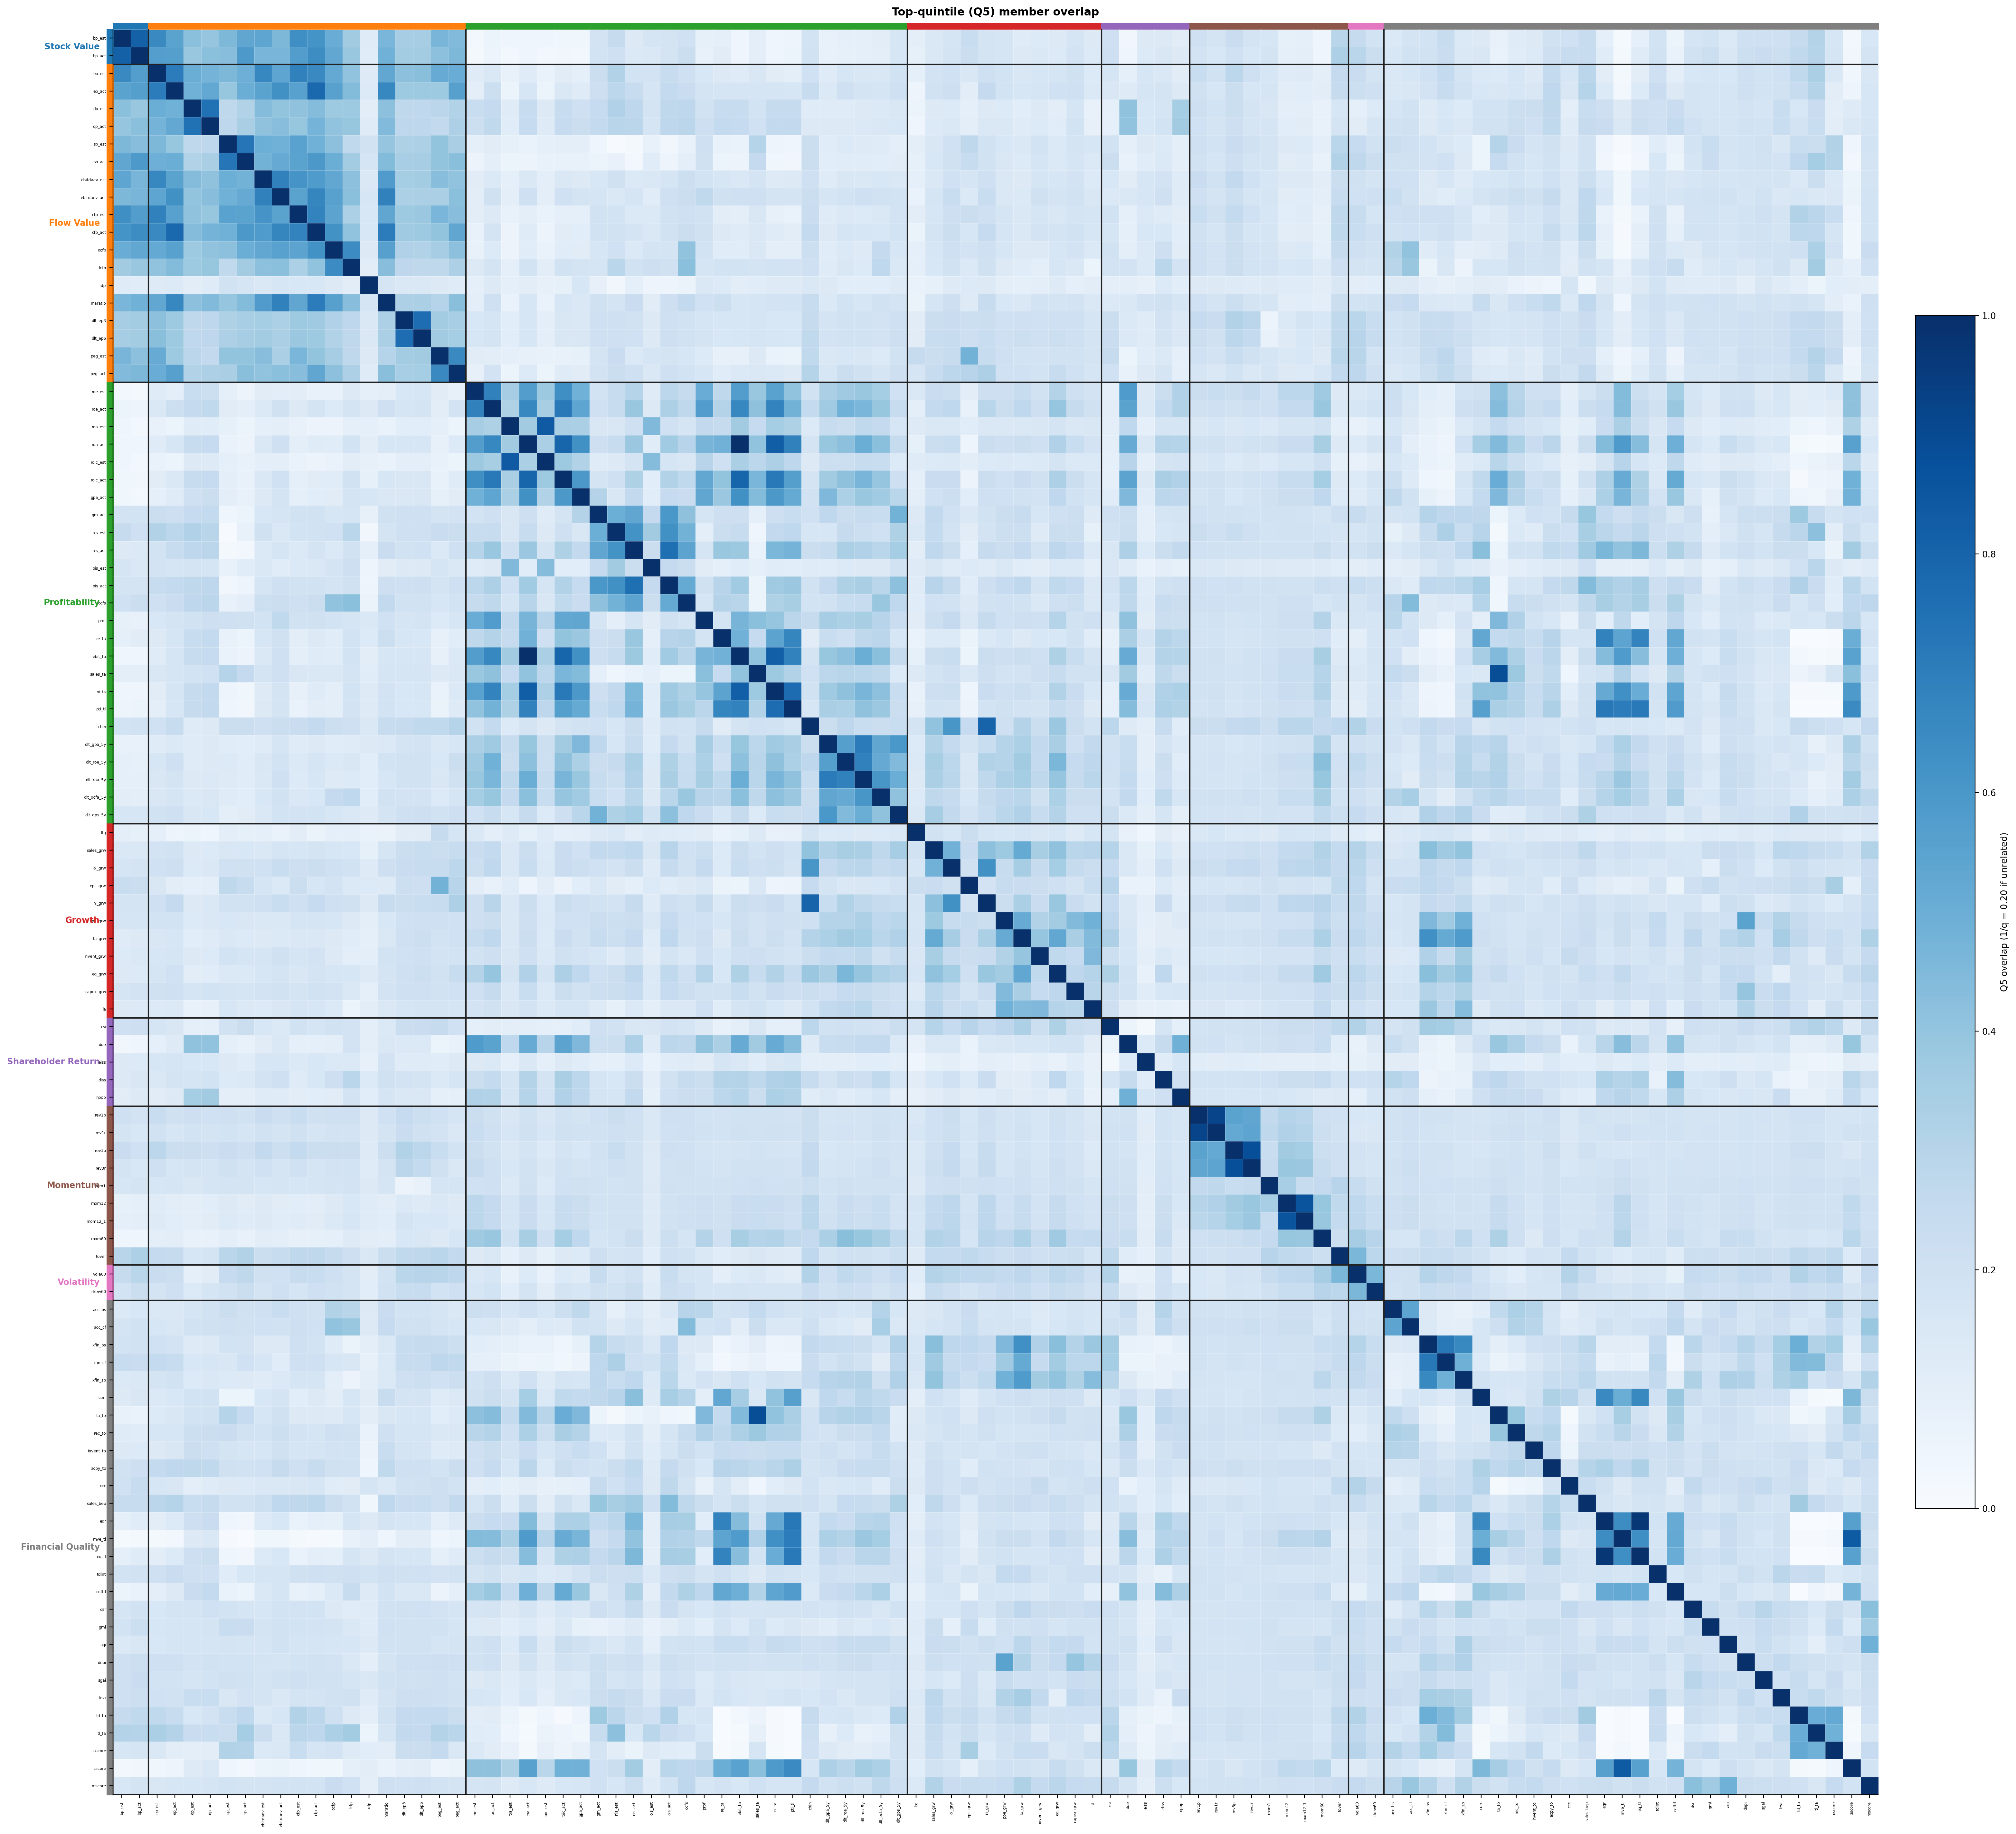

In [9]:
overlap_top = fl.multi.quantile_overlap(panel, [score_cols[f] for f in factors], q=Q,
                                        which="top", labels=factors)

fig = fl.plotting.plot_factor_matrix(
    overlap_top, groups=groups,
    title=f"Top-quintile (Q{Q}) member overlap",
    off_label=f"Q{Q} overlap (1/q = {1/Q:.2f} if unrelated)",
    off_cmap="Blues", off_vmin=0.0, off_vmax=1.0, annotate=False)
fl.plotting.savefig(fig, "05_core_scan/43_matrix_top_overlap");

## 5. 図C — 分散効果: Q5−Q1 リターン系列の相関

スコア相関（図A）は「並べ方の類似」、こちらは「損益の類似」。
合成ポートフォリオを考えるときに効くのはこちら。

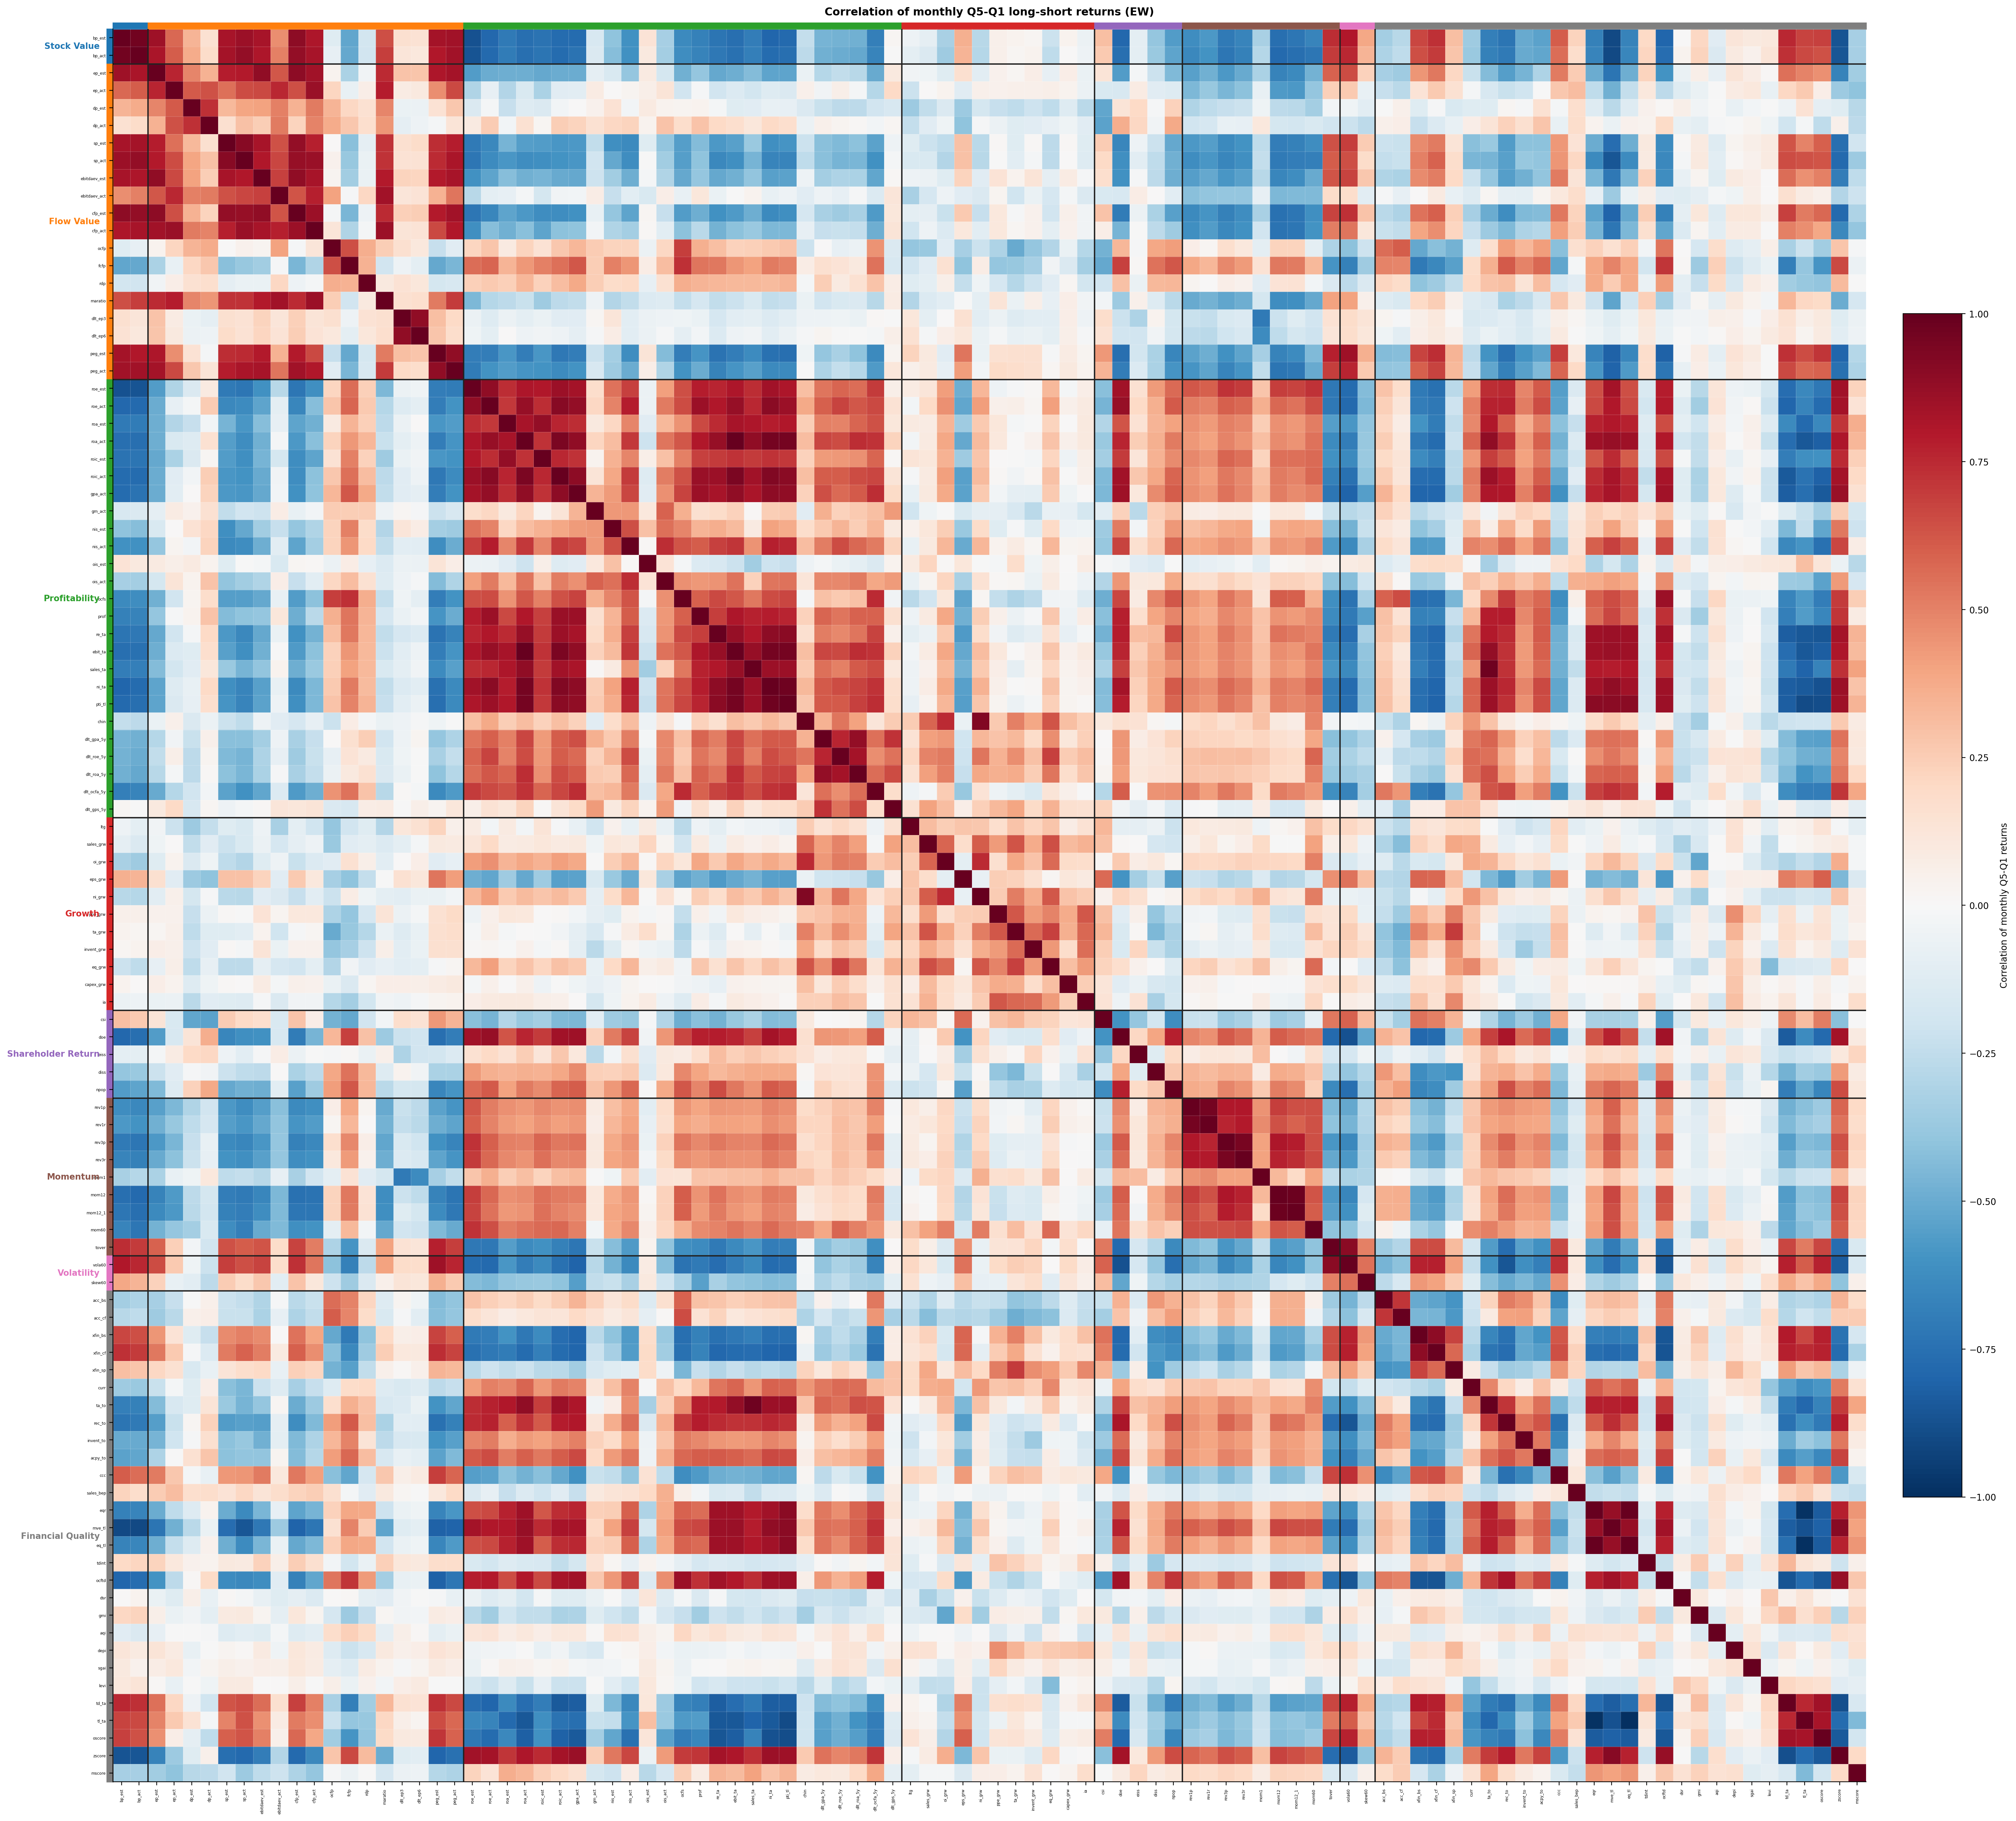

In [10]:
ls_returns = fl.multi.return_matrix(results, key=f"Q{Q}-Q1", weighting=WEIGHTING)
corr_ls = ls_returns.corr()

fig = fl.plotting.plot_factor_matrix(
    corr_ls, groups=groups,
    title=f"Correlation of monthly Q{Q}-Q1 long-short returns ({WEIGHTING.upper()})",
    off_label=f"Correlation of monthly Q{Q}-Q1 returns",
    off_vmin=-1, off_vmax=1, annotate=False)
fl.plotting.savefig(fig, "05_core_scan/44_matrix_ls_return_corr");

## 6. スタイル・レベルの要約（8×8、注釈つき）

各スタイルの合成スコア（構成ファクターの Blom スコア平均 → 再標準化）で
同じ分析を行う。8×8 なら数値を直接読める。

In [11]:
panel, style_cols = fl.multi.style_composite(panel, style_map, score_cols, method=METHOD)
style_groups = pd.Series({s: s for s in style_cols}, name="style")

sb_style, res_style = fl.multi.factor_scoreboard(
    panel, style_cols, groups=None, q=Q, weighting=WEIGHTING)
sb_style[["ls_ann_excess", "ls_IR", "ls_t_NW", "top_ann_excess", "top_IR", "top_t_NW",
          "mean_IC", "ICIR_ann", "ls_turnover_ann"]]

,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,ls_turnover_ann
Stock Value,-0.0031,0.0868,0.3794,-0.0332,0.0329,0.1458,-0.0165,-0.3095,2.9083
Flow Value,0.0720,0.5306,1.9547,-0.0011,0.1657,0.7261,0.0147,0.3720,5.0480
Profitability,-0.0054,0.0599,0.2705,-0.0037,-0.0440,-0.1877,0.0230,0.5046,2.5271
Growth,-0.0487,-0.3955,-1.3676,-0.0583,-0.2756,-1.1616,-0.0081,-0.3232,3.6379
Shareholder Return,0.0435,0.3921,1.5679,0.0210,0.1886,0.8887,0.0285,0.8717,5.0435
Momentum,0.1380,0.7763,3.2297,0.0906,0.7661,3.5071,0.0499,1.0932,10.1504
Volatility,-0.0844,-0.3666,-1.6455,-0.0875,-0.2755,-1.2799,-0.0494,-1.0404,2.5982
Financial Quality,-0.0537,-0.3597,-1.5298,-0.0430,-0.4598,-1.9003,-0.0040,-0.1191,3.1358


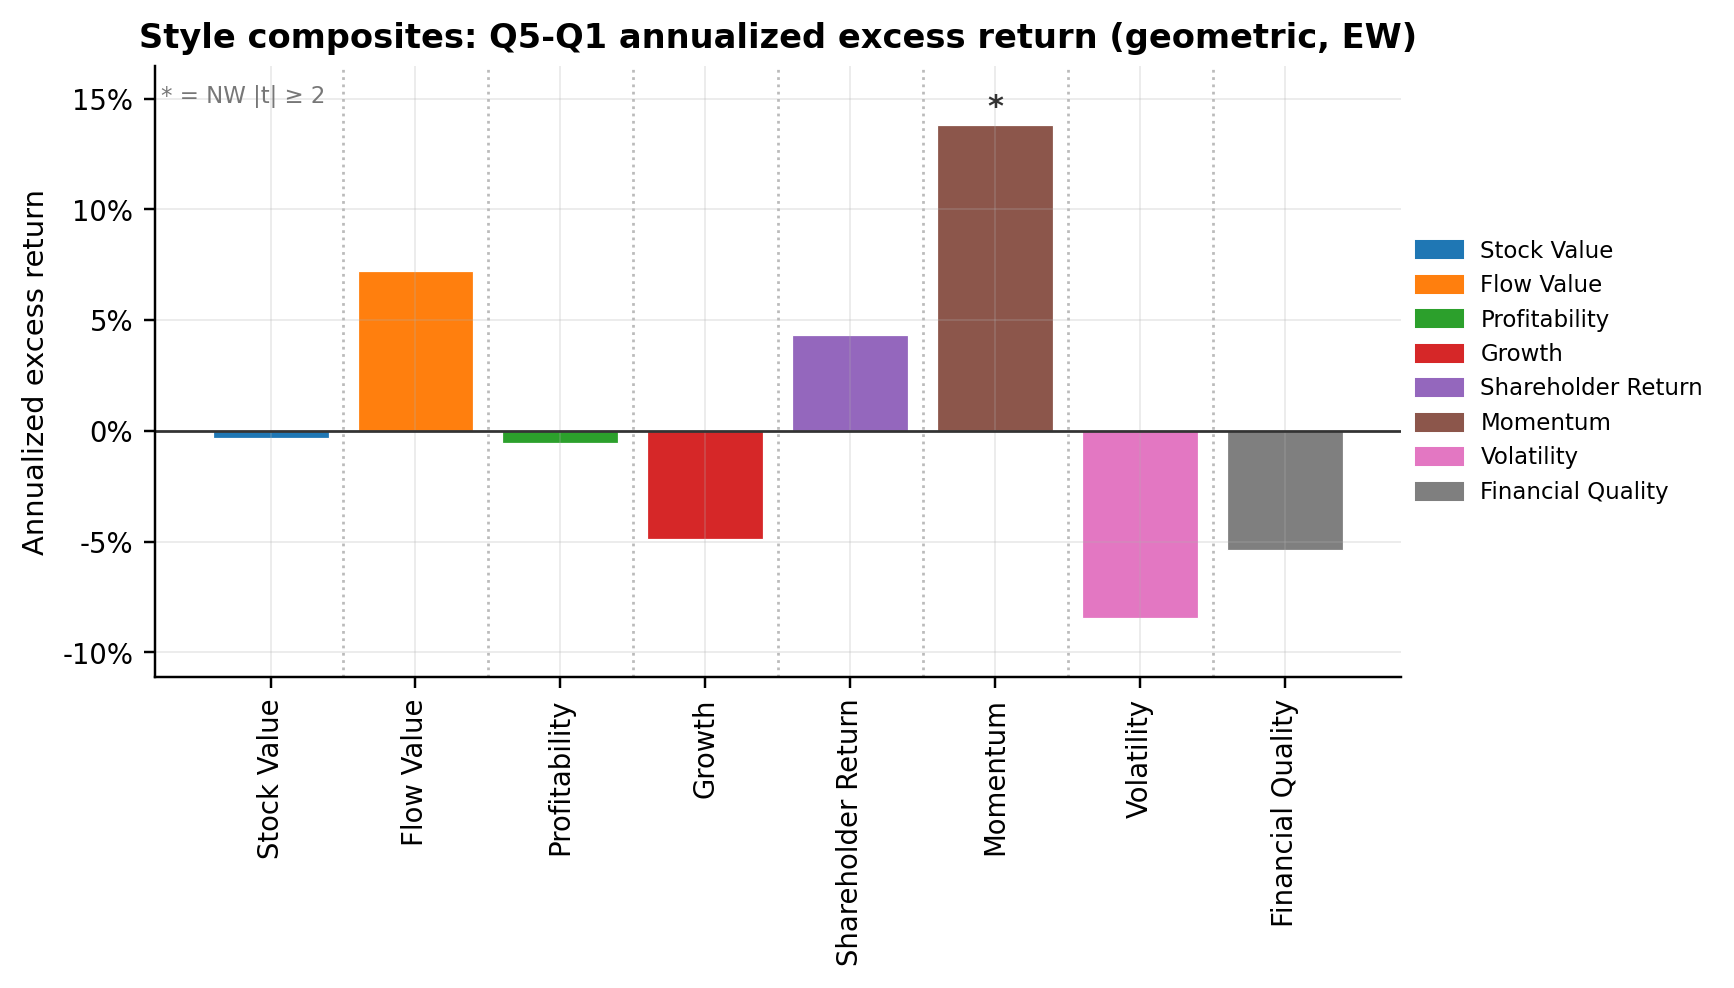

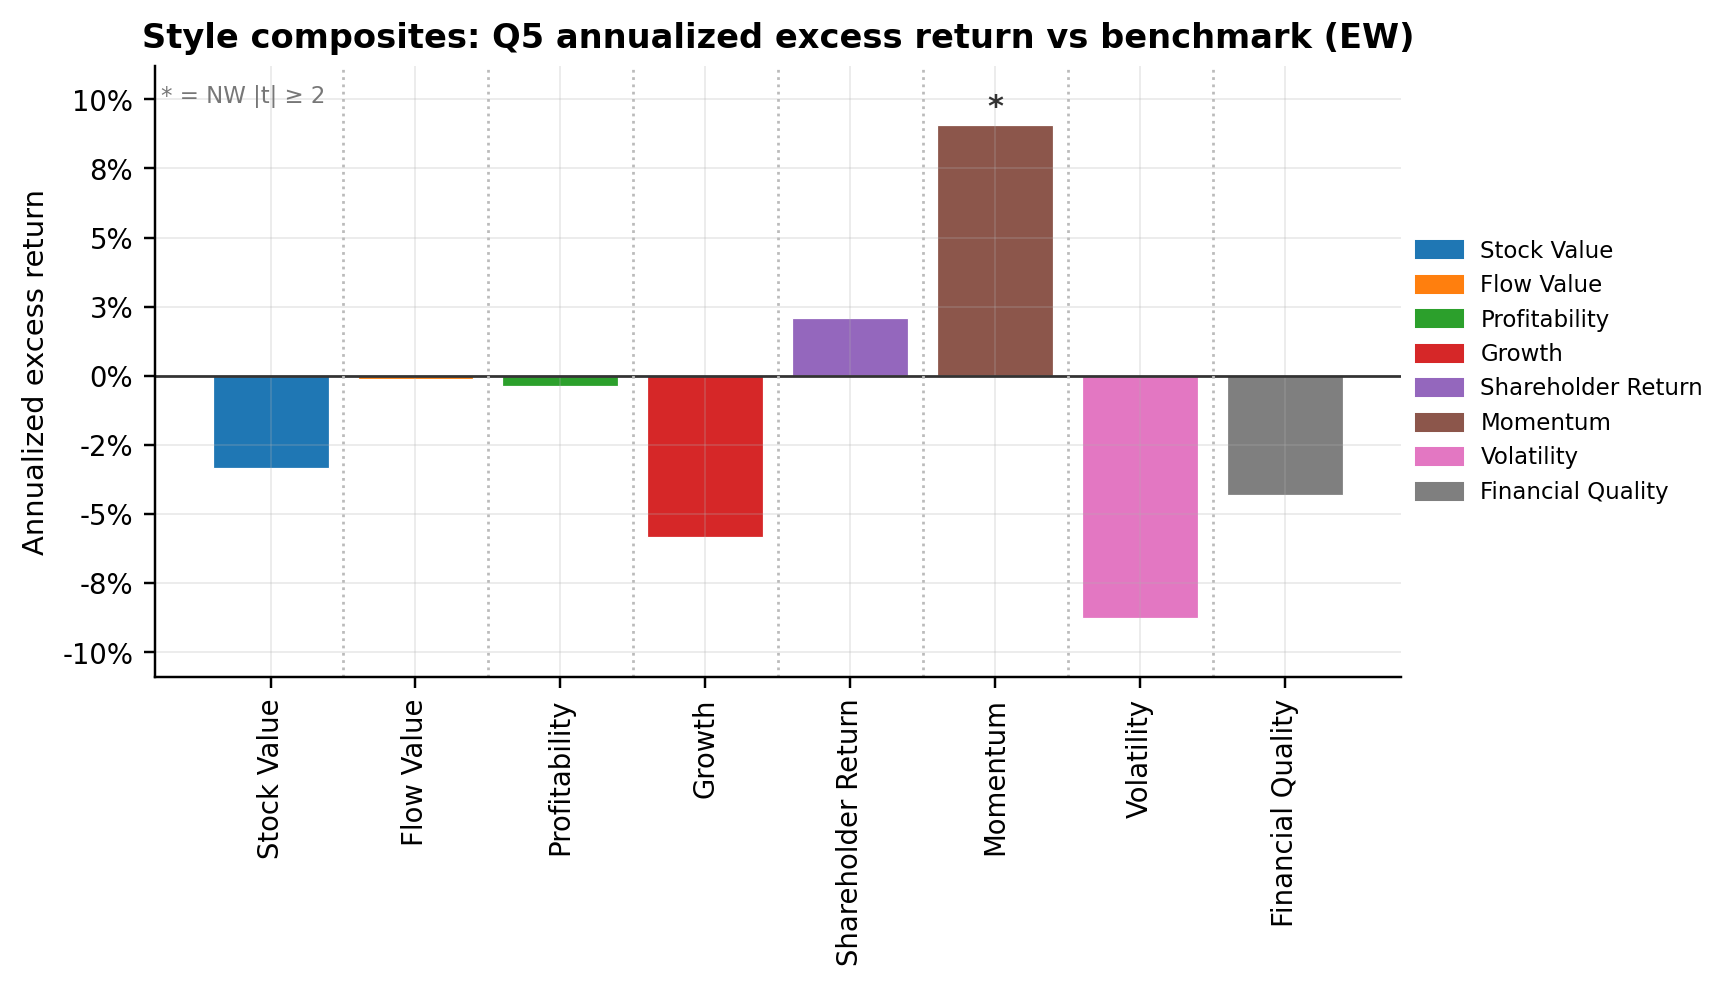

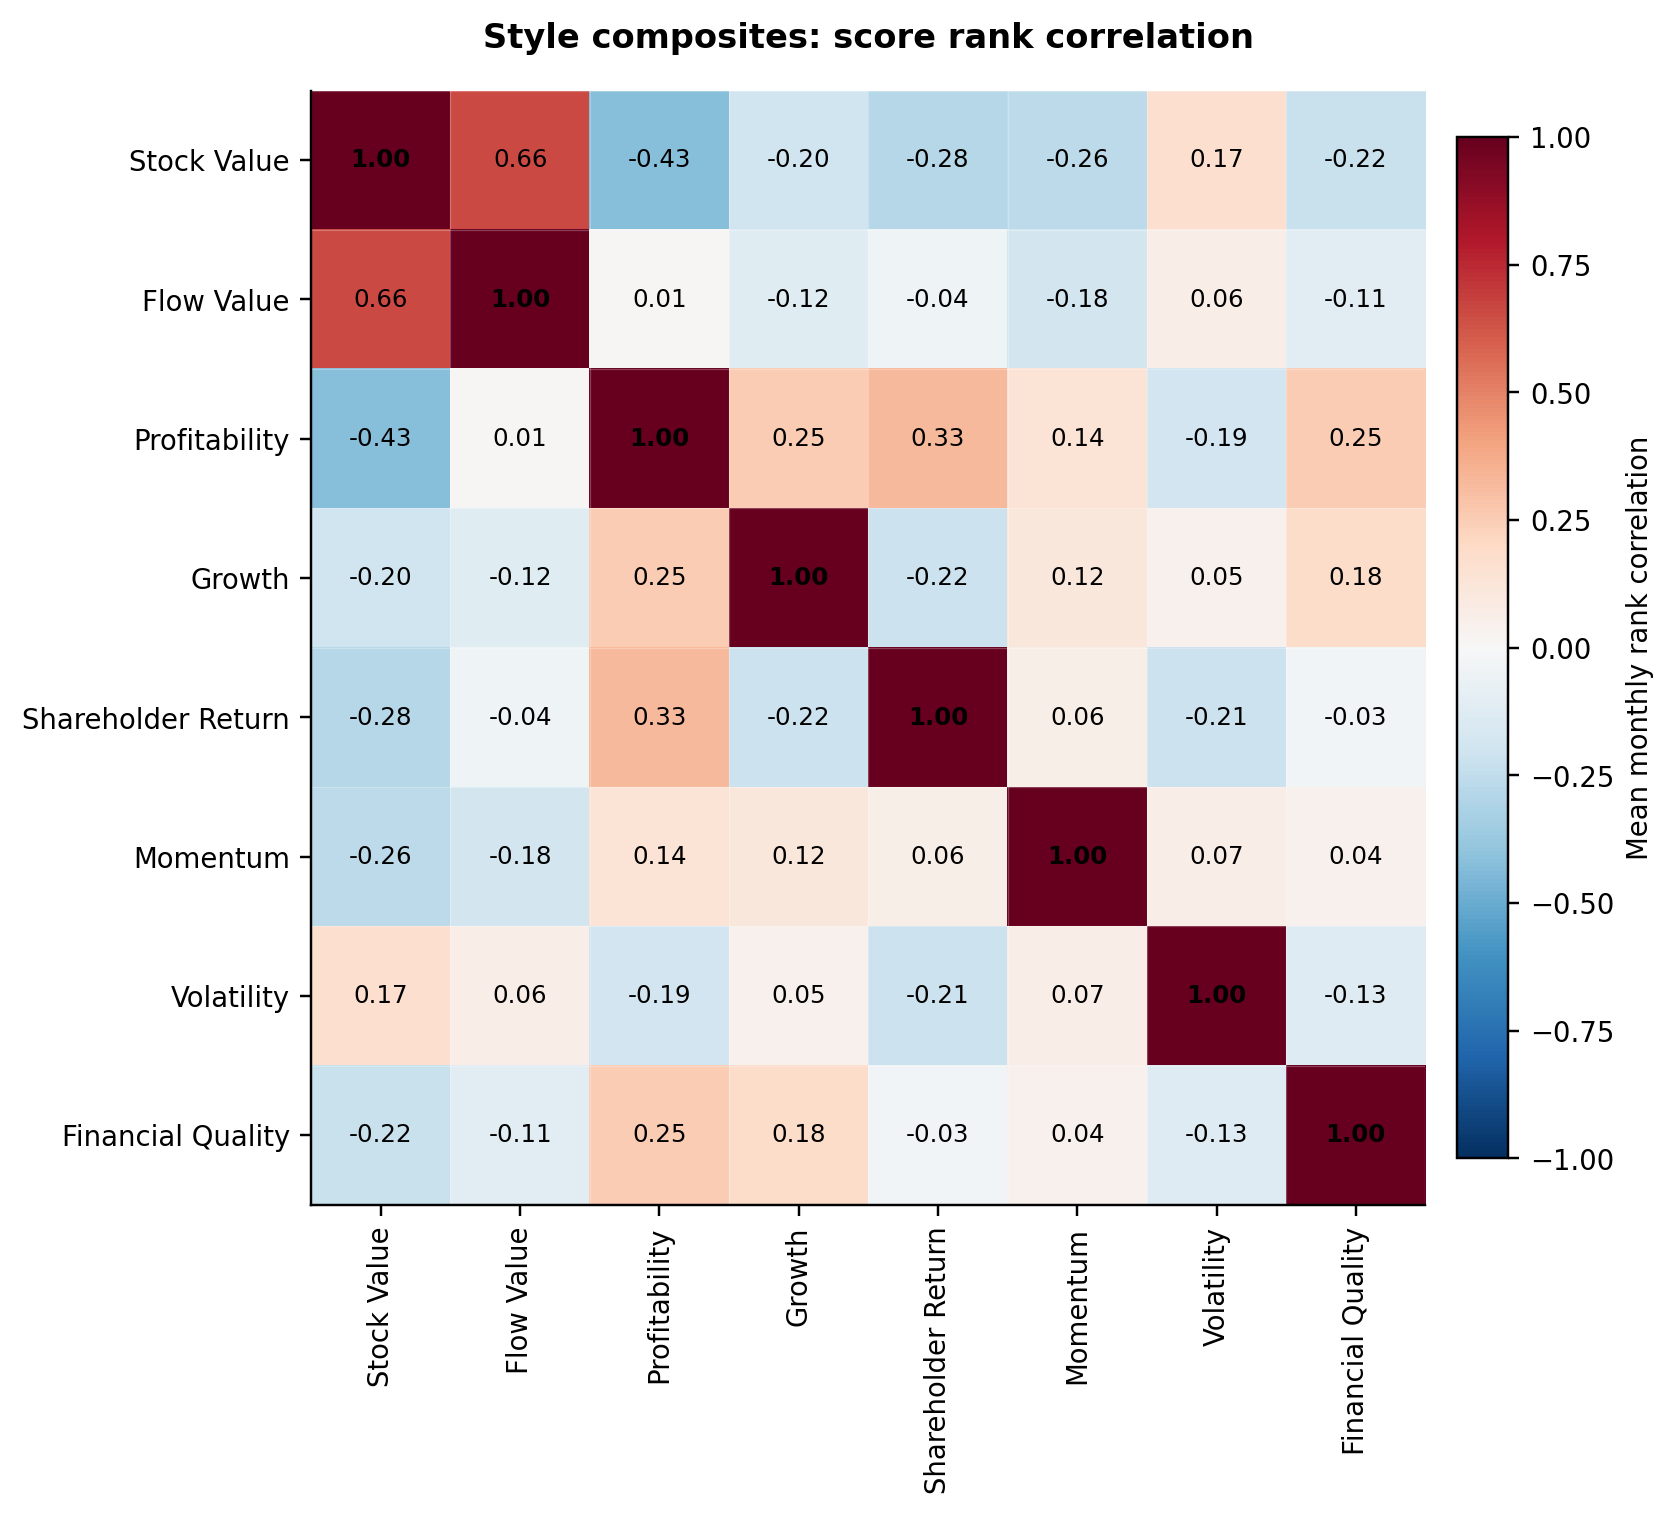

In [12]:
sb_style_named = sb_style.copy()
sb_style_named["style"] = sb_style_named.index
fig = fl.plotting.plot_scoreboard_bars(
    sb_style_named, value_col="ls_ann_excess", tstat_col="ls_t_NW",
    title=f"Style composites: Q{Q}-Q1 annualized excess return (geometric, {WEIGHTING.upper()})",
    sort_within_group=False, figsize=(8.0, 4.6))
fl.plotting.savefig(fig, "05_core_scan/45a_style_bars_ls");

fig = fl.plotting.plot_scoreboard_bars(
    sb_style_named, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Style composites: Q{Q} annualized excess return vs benchmark ({WEIGHTING.upper()})",
    sort_within_group=False, figsize=(8.0, 4.6))
fl.plotting.savefig(fig, "05_core_scan/45b_style_bars_top");

corr_style = fl.multi.cross_sectional_corr(panel, list(style_cols.values()),
                                           labels=list(style_cols.keys()))
fig = fl.plotting.plot_factor_matrix(
    corr_style,
    title="Style composites: score rank correlation",
    off_label="Mean monthly rank correlation",
    off_vmin=-1, off_vmax=1, annotate=True, figsize=(8.6, 7.0), band=0.0)
fl.plotting.savefig(fig, "05_core_scan/45_matrix_style");

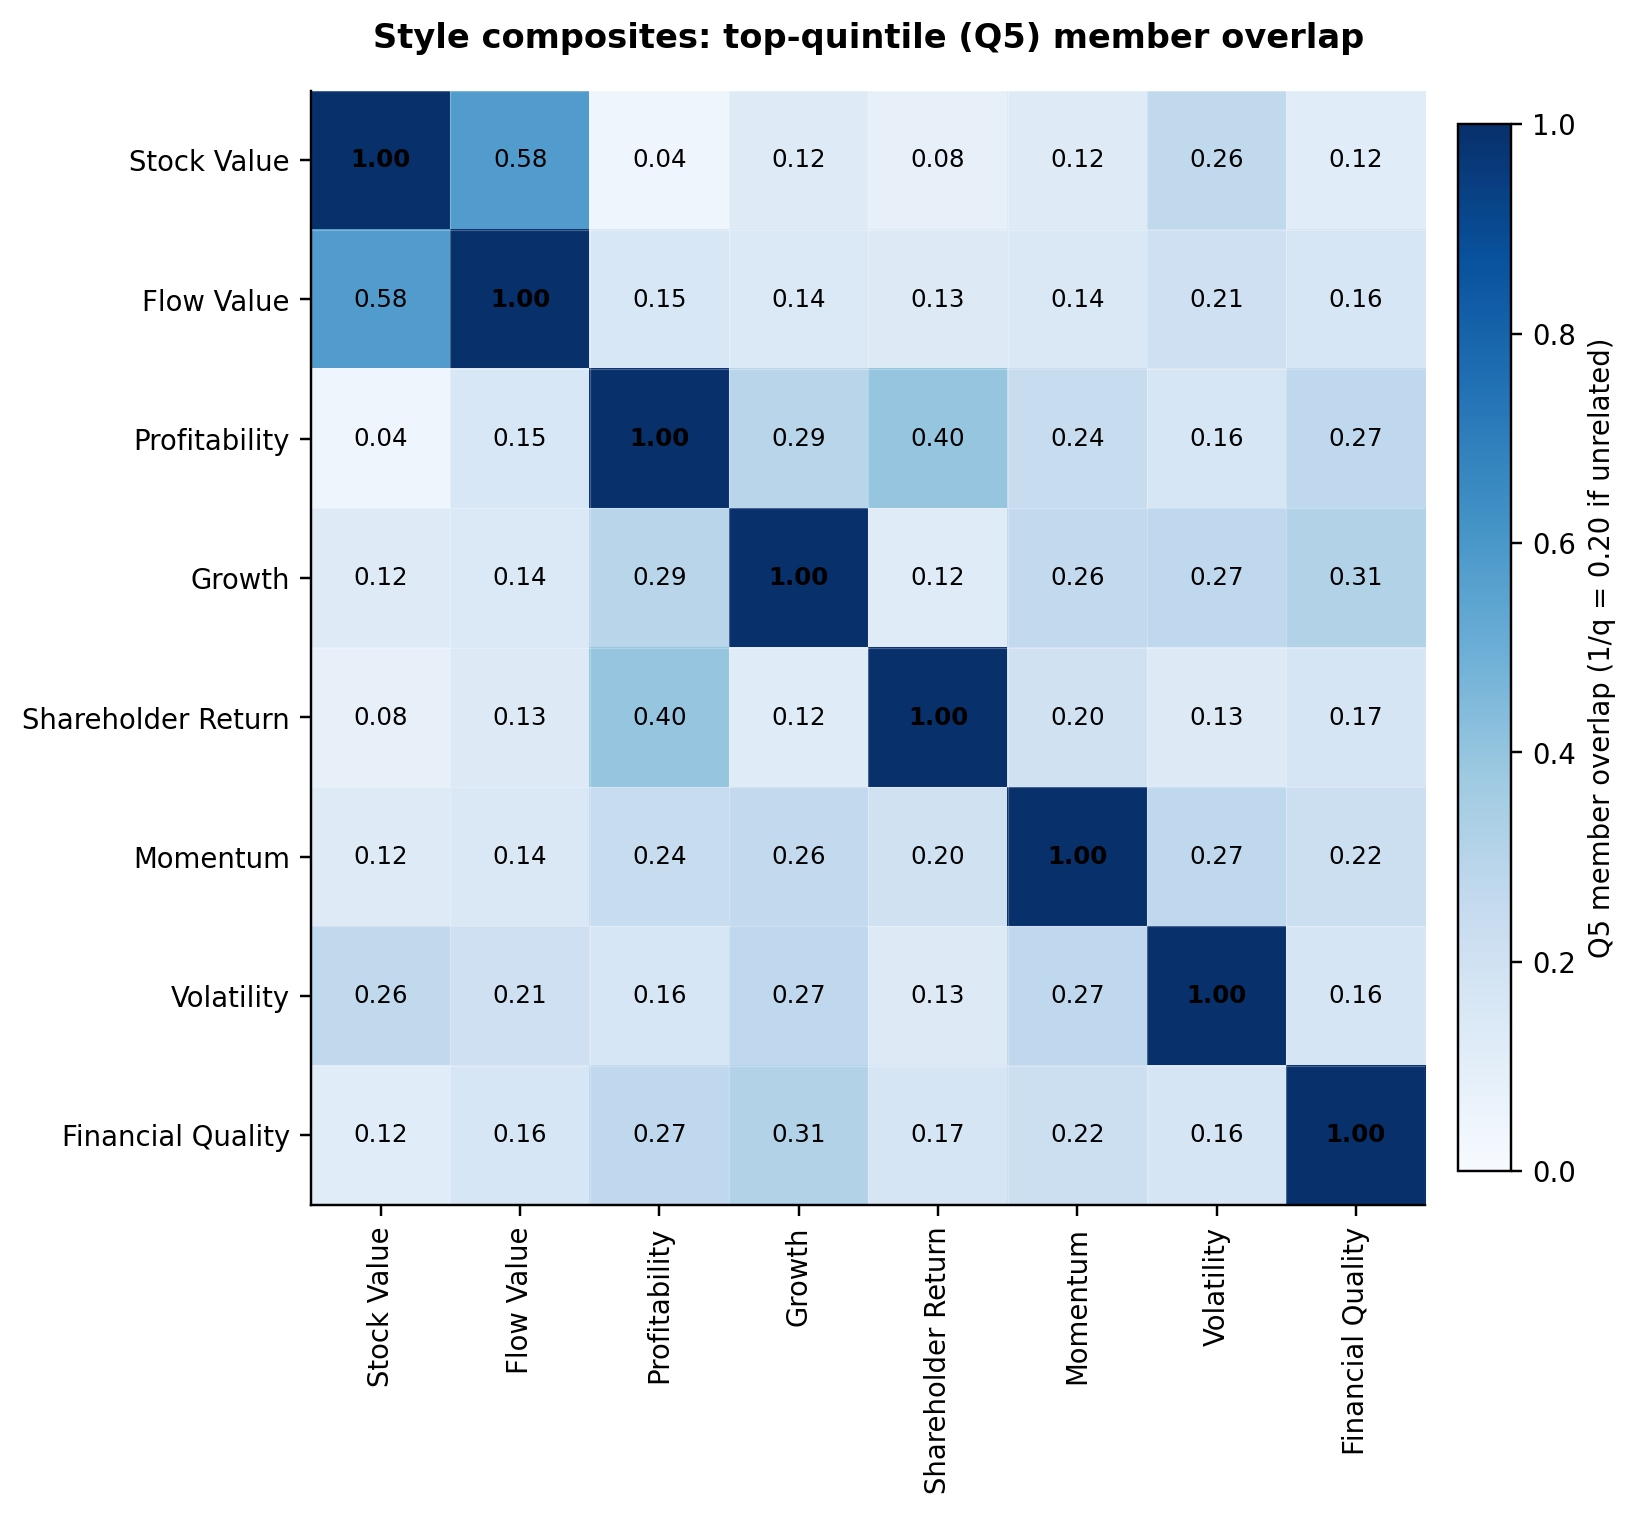

In [13]:
overlap_style = fl.multi.quantile_overlap(panel, list(style_cols.values()), q=Q,
                                          which="top", labels=list(style_cols.keys()))
fig = fl.plotting.plot_factor_matrix(
    overlap_style,
    title=f"Style composites: top-quintile (Q{Q}) member overlap",
    off_label=f"Q{Q} member overlap (1/q = {1/Q:.2f} if unrelated)",
    off_cmap="Blues", off_vmin=0.0, off_vmax=1.0, annotate=True, figsize=(8.6, 7.0), band=0.0)
fl.plotting.savefig(fig, "05_core_scan/46_matrix_style_overlap");

## 7. 中立化版（size + sector neutral）

Step 3 の規約どおり「Blom → セクターダミー + log(Cap) のクロスセクション回帰残差」で
全ファクターを中立化し、**Q5 年率超過（縦棒）とスコア相関行列のみ**を見る。

- 中立化で **Q5 が残るか** = セクター・サイズ配分ではなく銘柄選別で効いているか
- 中立化で **相関構造がどう縮むか** = 共通のセクター/サイズ露出を除いた「素の類似度」

In [14]:
panel, _ = fl.multi.build_scores(panel, factors, method=METHOD,
                                 group_col="sector", control_cols=["log_cap"],
                                 suffix=f"_{METHOD}_ss")
score_cols_ss = {f: f"{f}_{METHOD}_ss" for f in factors}

sb_ss, _ = fl.multi.factor_scoreboard(panel, score_cols_ss, groups=groups, q=Q, weighting=WEIGHTING)
cmp_top = pd.DataFrame({
    "raw": scoreboard["top_ann_excess"],
    "size_sector": sb_ss["top_ann_excess"],
})
cmp_top["diff"] = cmp_top["size_sector"] - cmp_top["raw"]
print("中立化で Q5 超過が最も改善 / 悪化したファクター:")
display(cmp_top.sort_values("diff", ascending=False).head(8))
display(cmp_top.sort_values("diff").head(8))

中立化で Q5 超過が最も改善 / 悪化したファクター:


,raw,size_sector,diff
dlt_ep3,-0.0138,0.0176,0.0315
dlt_ep6,-0.0383,-0.0139,0.0244
tover,-0.0577,-0.0345,0.0232
maratio,0.0074,0.0270,0.0196
dlt_gpa_5y,-0.0589,-0.0414,0.0175
dlt_roa_5y,-0.0580,-0.0428,0.0152
peg_est,-0.0404,-0.0258,0.0147
eiss,-0.0267,-0.0121,0.0145


,raw,size_sector,diff
ois_est,0.0052,-0.0322,-0.0374
sales_bep,-0.0464,-0.0701,-0.0237
nis_est,0.0002,-0.0224,-0.0226
tl_ta,0.0100,-0.0106,-0.0206
eqr,0.0033,-0.0166,-0.0198
ois_act,-0.0163,-0.0345,-0.0182
eq_tl,0.0042,-0.0137,-0.0178
mom1,-0.0248,-0.0417,-0.0168


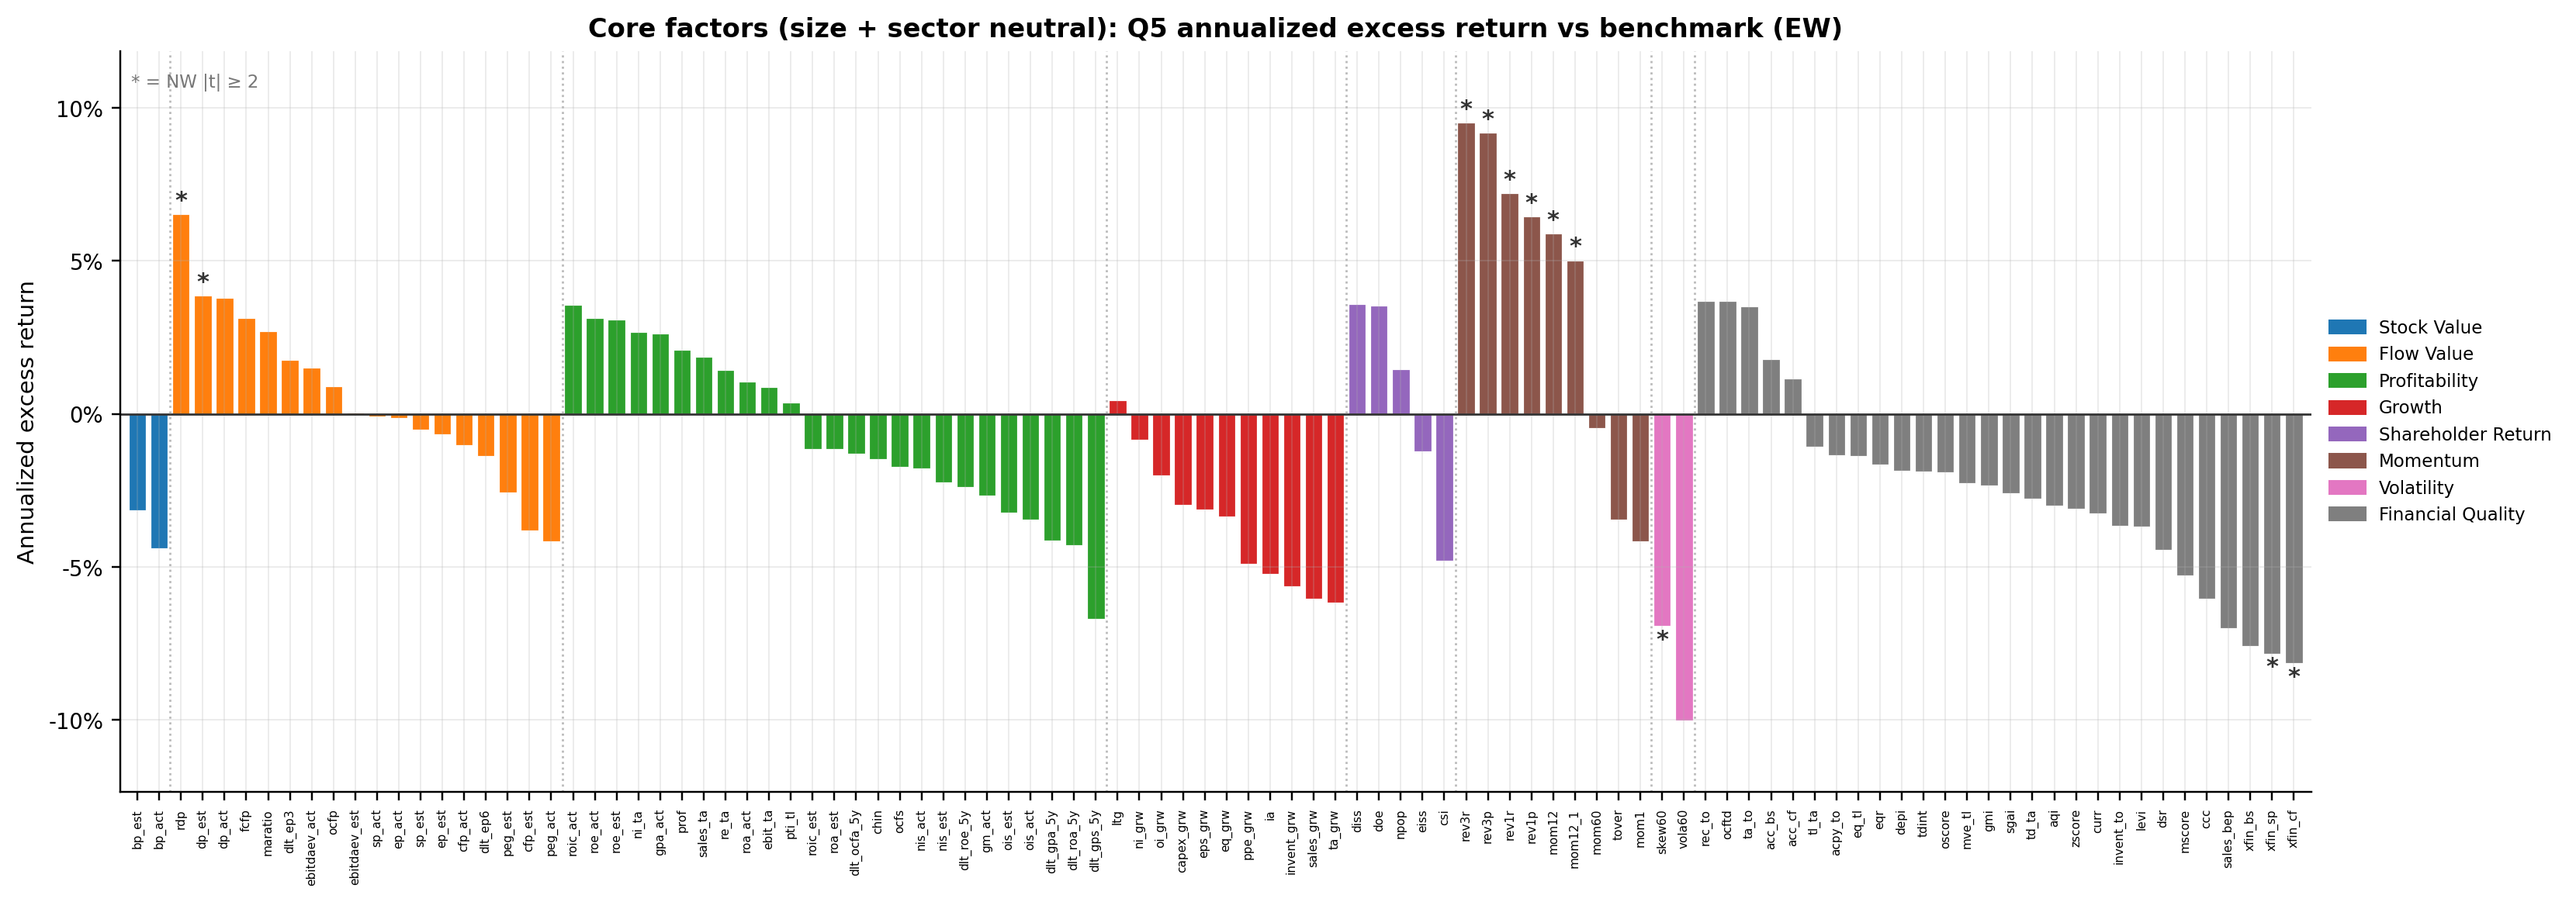

In [15]:
fig = fl.plotting.plot_scoreboard_bars(
    sb_ss, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Core factors (size + sector neutral): Q{Q} annualized excess return vs benchmark ({WEIGHTING.upper()})")
fl.plotting.savefig(fig, "05_core_scan/47_scoreboard_top_neutral");

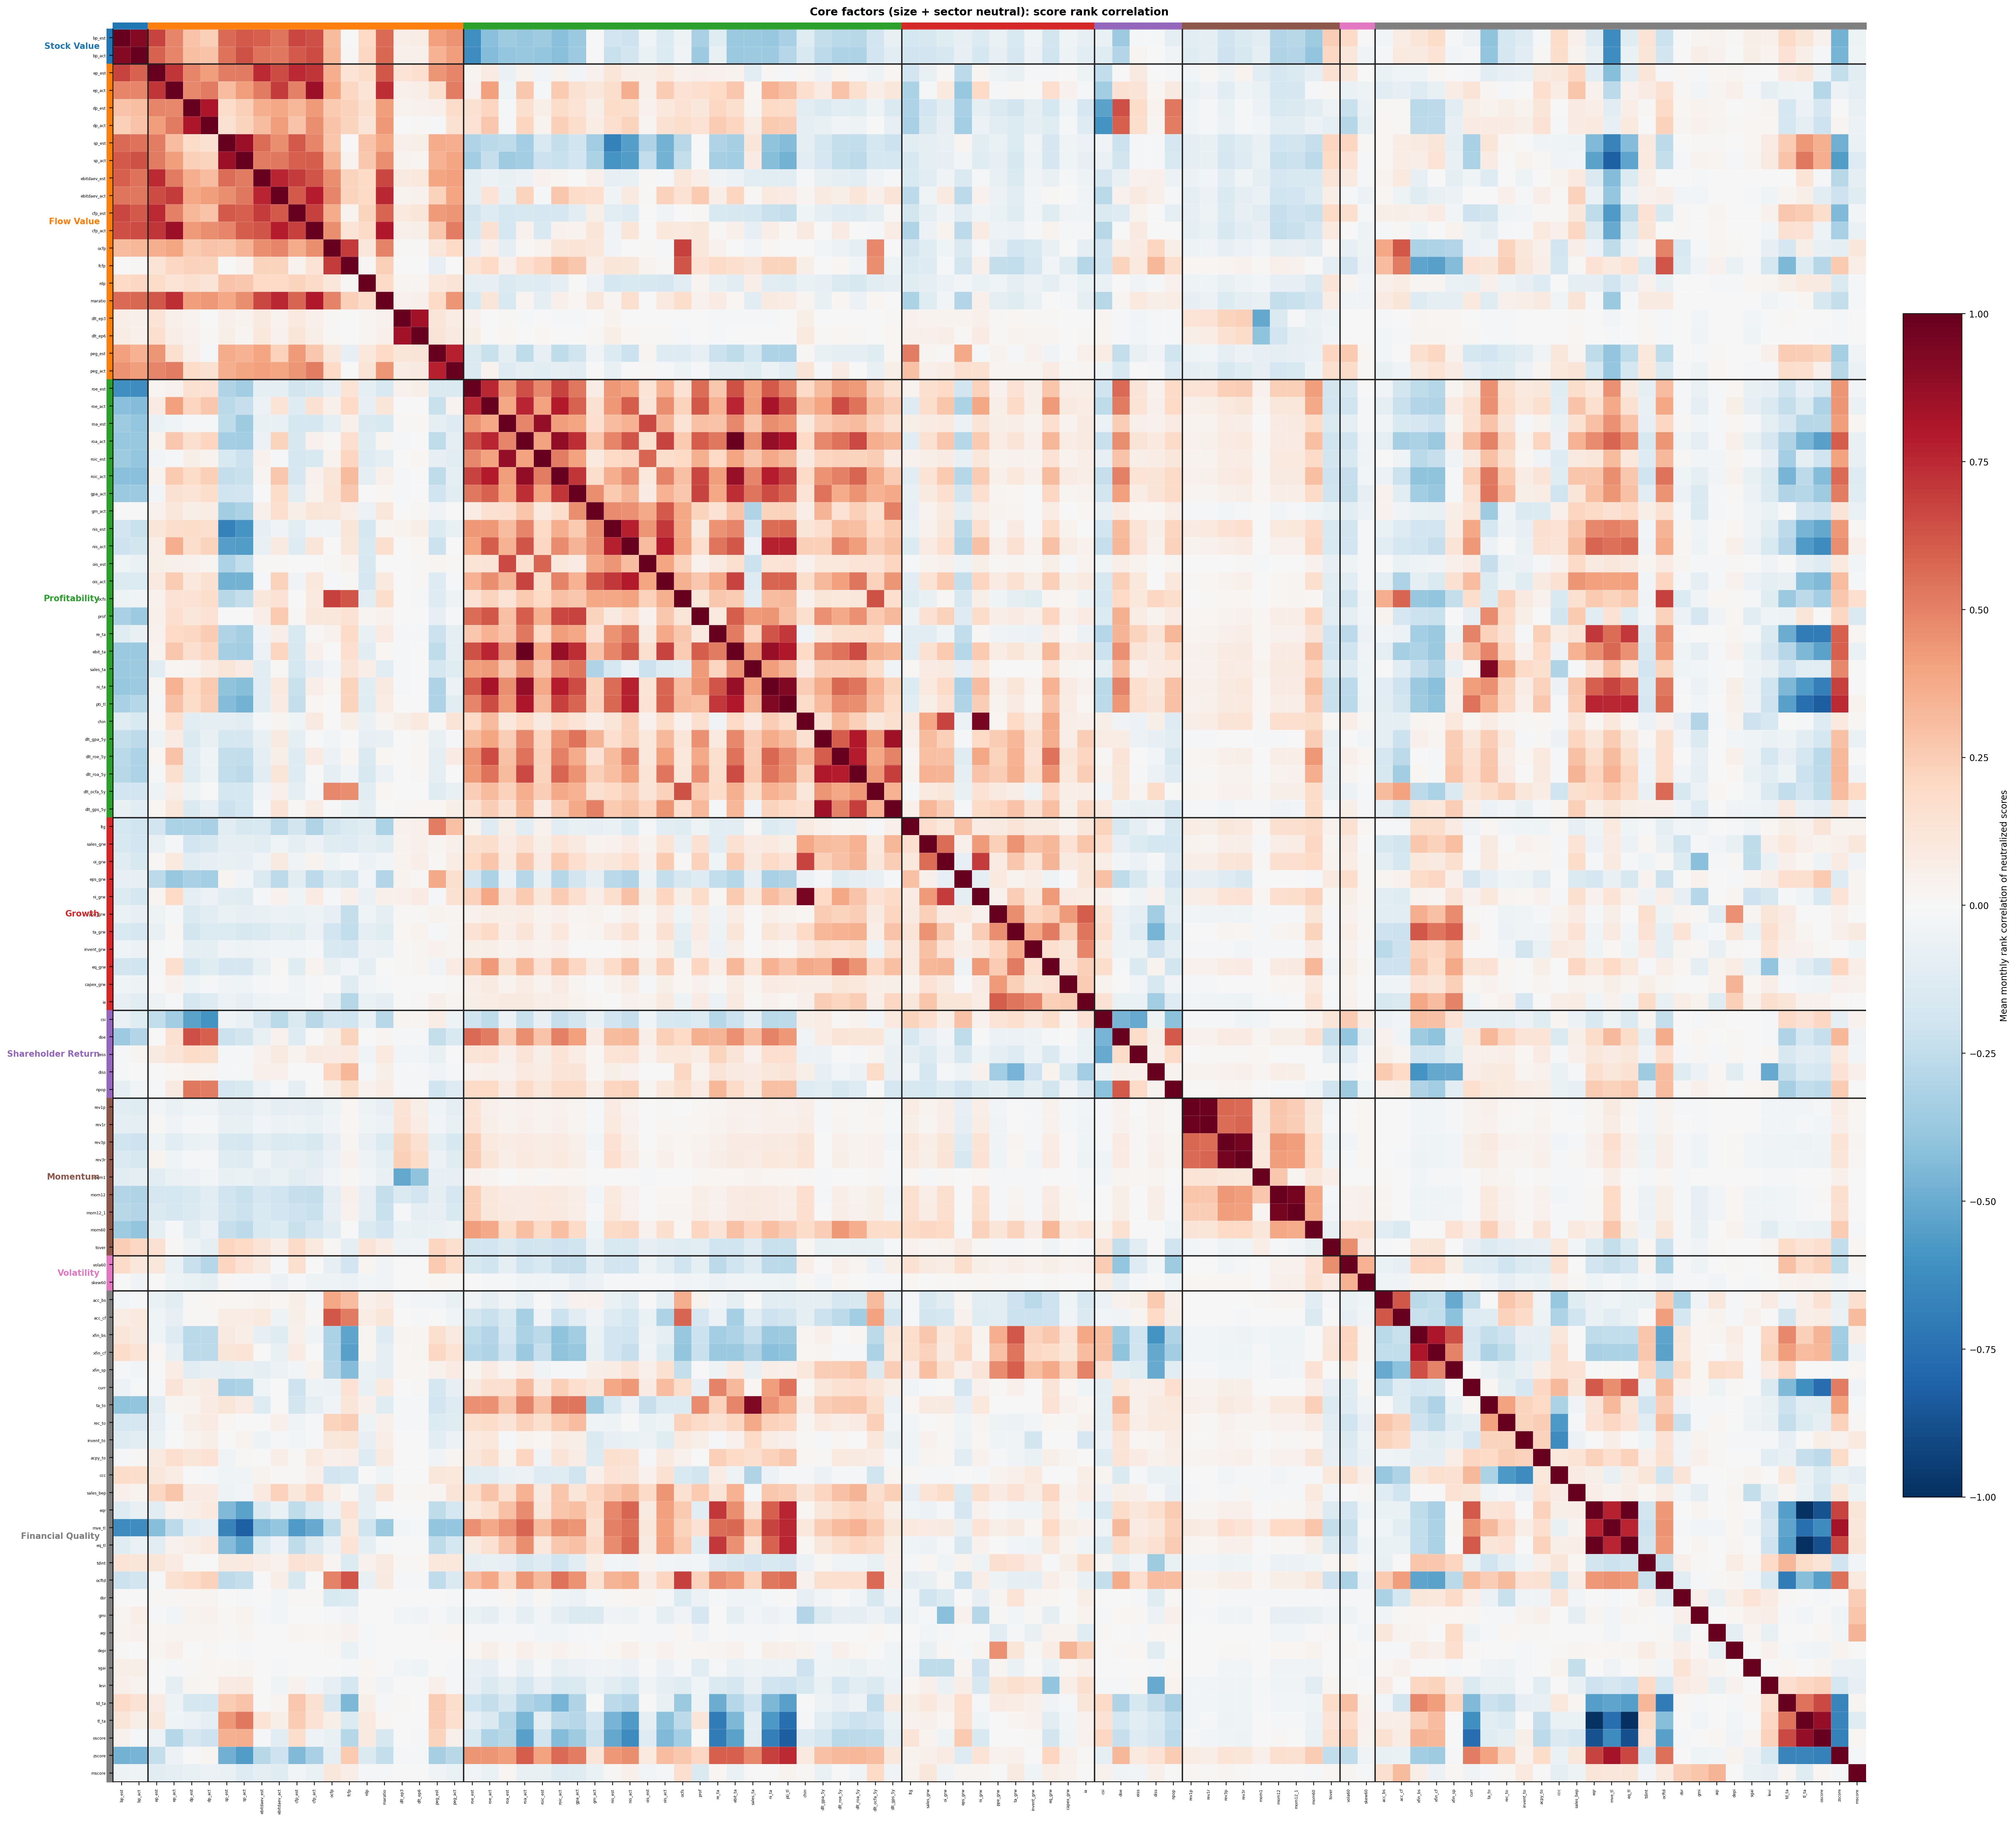

In [16]:
corr_score_ss = fl.multi.cross_sectional_corr(panel, [score_cols_ss[f] for f in factors], labels=factors)
fig = fl.plotting.plot_factor_matrix(
    corr_score_ss, groups=groups,
    title="Core factors (size + sector neutral): score rank correlation",
    off_label="Mean monthly rank correlation of neutralized scores",
    off_vmin=-1, off_vmax=1, annotate=False)
fl.plotting.savefig(fig, "05_core_scan/48_matrix_score_corr_neutral");

---

## 使い方メモ

- ファクター単位で深掘りしたいものが見つかったら、Step 1〜4 のノートに
  `FACTOR = "..."` を差し替えて回す
- 中立化して比較したい場合は `fl.multi.build_scores(panel, factors, group_col="sector",
  control_cols=["log_cap"])` に変えるだけで全行列が size+sector 中立版になる
- `WEIGHTING = "cw"` にすると分位ポート側がすべて時価総額ウェイトになる